In [16]:
import json
import pandas as pd

from datetime import datetime
from pathlib import Path
from building_models.training_models.exploratory_performance import *

### Exploratory analysis of training results

This notebook analyzes the performance results obtained from the complete set of model-training experiments. The input file, `all_results_aggregated_fixed.csv`, is generated by executing the `aggregate_training_results.py` script, which discovers the individual training-result files, extracts their experimental, and aggregates the fold-level metrics into a single table.

The aggregated results are prepared for analysis by standardizing labels. The notebook then evaluates how model performance is affected by the partition strategy, redundancy-reduction strategy, reduction level, numerical representation, classification algorithm, and feature normalization. Performance is primarily assessed using the test F1-score and Matthews correlation coefficient (MCC).

In addition to comparing the observed metric distributions, the notebook calculates performance differences relative to reference experimental conditions, including no redundancy reduction, random partitioning, and no feature normalization. These comparisons are used to identify which representations and algorithms are most sensitive to changes in dataset construction and evaluation strategy.

Finally, the prepared results, calculated performance deltas, and reproducibility metadata are saved as CSV and JSON files for use in downstream analyses and visualization notebooks.

- Read results (File with all training results)

In [17]:
folder_path = "../../analysed_training"
results_all = (
    pd.read_csv(Path(folder_path) / "all_results_aggregated_final.csv")
    .query("algorithm != 'LGBMClassifier'")
    .copy()
)

results = prepare_results_for_analysis(results_all) # Prepare the columns for analysis
results

,experiment_dir,representation_clean,reduction_strategy_clean,reduced_by,split_space_clean,reduction_level,reduction_percentile,homology_threshold,algorithm,partition_strategy,...,f1_test_n,mcc_test_mean,mcc_test_std,mcc_test_n,result_origin,representation_label,reduced_by_label,partition_label,reduction_label,reduction_level_label
0,ankh2_ext1_no_reduced,ankh2_ext1,no_reduction,none,ankh2_ext1,no_level,not_applicable,not_applicable,DecisionTreeClassifier,distance_aware_kfold,...,5,0.559384,0.146547,5,historical,Ankh2,none,Distance-aware,No reduction,no_level
1,ankh2_ext1_no_reduced,ankh2_ext1,no_reduction,none,ankh2_ext1,no_level,not_applicable,not_applicable,DecisionTreeClassifier,distance_aware_kfold,...,5,0.604498,0.257667,5,historical,Ankh2,none,Distance-aware,No reduction,no_level
2,ankh2_ext1_no_reduced,ankh2_ext1,no_reduction,none,ankh2_ext1,no_level,not_applicable,not_applicable,DecisionTreeClassifier,distance_aware_kfold,...,5,0.606285,0.224870,5,historical,Ankh2,none,Distance-aware,No reduction,no_level
3,ankh2_ext1_no_reduced,ankh2_ext1,no_reduction,none,ankh2_ext1,no_level,not_applicable,not_applicable,DecisionTreeClassifier,distance_aware_kfold,...,5,0.583536,0.263036,5,historical,Ankh2,none,Distance-aware,No reduction,no_level
4,ankh2_ext1_no_reduced,ankh2_ext1,no_reduction,none,ankh2_ext1,no_level,not_applicable,not_applicable,DecisionTreeClassifier,distance_aware_kfold,...,5,0.579836,0.284004,5,historical,Ankh2,none,Distance-aware,No reduction,no_level
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1966315,onehot_reduced_distance_by_prot_t5_xl_uniref50,onehot,distance_reduction,prot_t5_xl_uniref50,not_applicable,p99_9,p99_9,not_applicable,SVC,stratified_kfold,...,5,0.464048,0.048748,5,corrected_onehot_replacement,One-hot,ProtT5,Stratified,Distance reduction,p99_9
1966316,onehot_reduced_distance_by_prot_t5_xl_uniref50,onehot,distance_reduction,prot_t5_xl_uniref50,not_applicable,p99_9,p99_9,not_applicable,XGBClassifier,stratified_kfold,...,5,0.411390,0.032342,5,corrected_onehot_replacement,One-hot,ProtT5,Stratified,Distance reduction,p99_9
1966317,onehot_reduced_distance_by_prot_t5_xl_uniref50,onehot,distance_reduction,prot_t5_xl_uniref50,not_applicable,p99_9,p99_9,not_applicable,XGBClassifier,stratified_kfold,...,5,0.453854,0.040777,5,corrected_onehot_replacement,One-hot,ProtT5,Stratified,Distance reduction,p99_9
1966318,onehot_reduced_distance_by_prot_t5_xl_uniref50,onehot,distance_reduction,prot_t5_xl_uniref50,not_applicable,p99_9,p99_9,not_applicable,XGBClassifier,stratified_kfold,...,5,0.456739,0.045869,5,corrected_onehot_replacement,One-hot,ProtT5,Stratified,Distance reduction,p99_9


- Question 1: How does the division strategy affect it?

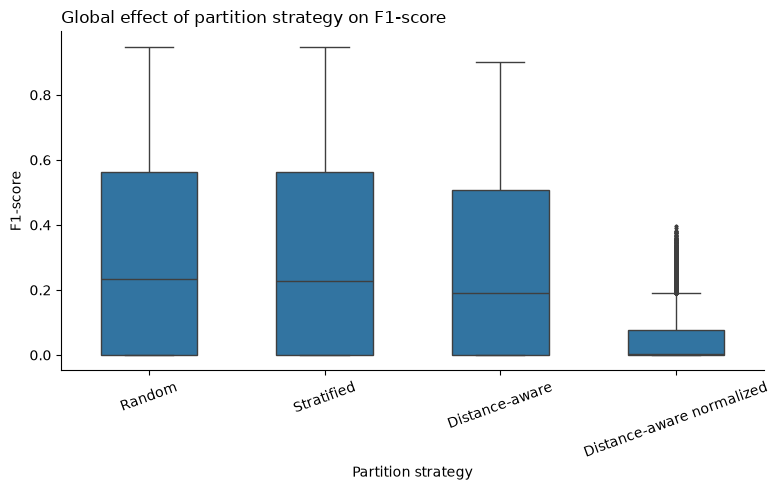

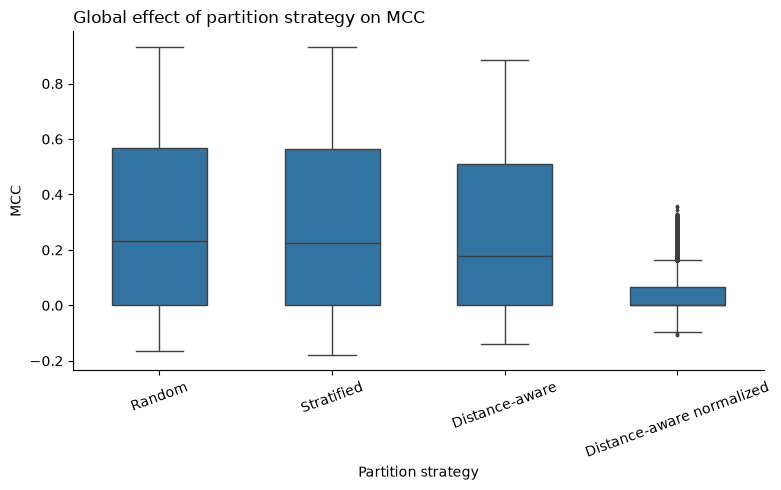

In [18]:
plot_partition_effect_global(
    results,
    metric="f1_test_mean",
    ylabel="F1-score",
    title="Global effect of partition strategy on F1-score"
)

plot_partition_effect_global(
    results,
    metric="mcc_test_mean",
    ylabel="MCC",
    title="Global effect of partition strategy on MCC"
)

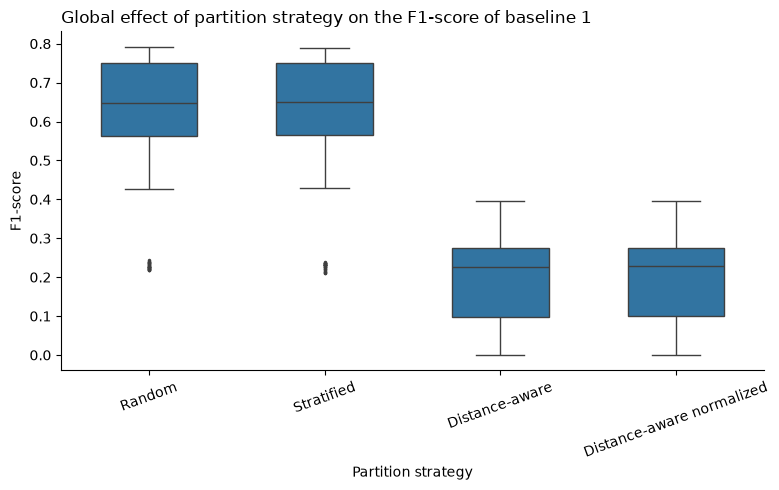

In [19]:
b1 = results[(results["reduction_strategy_clean"] == "no_reduction") & (results["representation_clean"] == "onehot")] # Baseline 1 corresponds to One Hot coding
plot_partition_effect_global(
    b1,
    metric="f1_test_mean",
    ylabel="F1-score",
    title="Global effect of partition strategy on the F1-score of baseline 1"
)

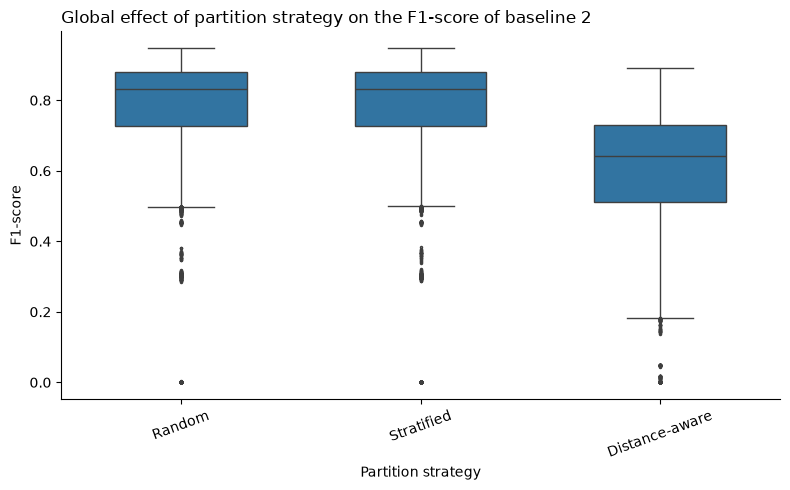

In [20]:
b2 = results[(results["reduction_strategy_clean"] == "no_reduction") & (results["representation_clean"] != "onehot")] # Baseline 1 corresponds to embeddings
plot_partition_effect_global(
    b2,
    metric="f1_test_mean",
    ylabel="F1-score",
    title="Global effect of partition strategy on the F1-score of baseline 2"
)

- Question 2: How does the reduction strategy affect it?

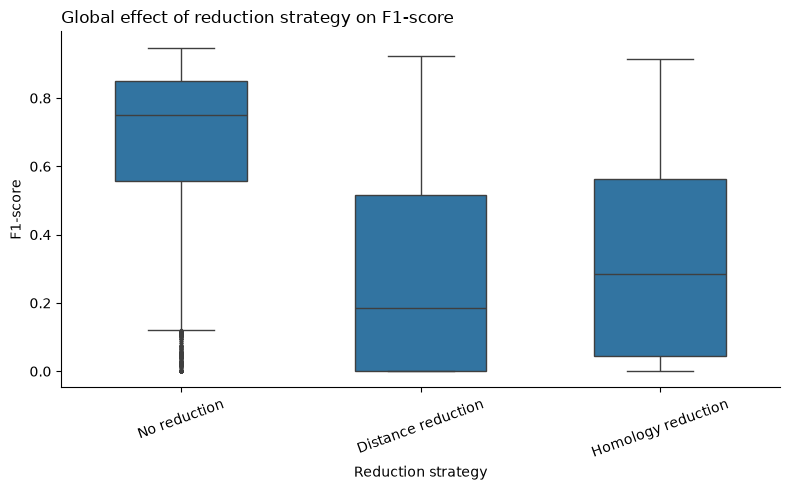

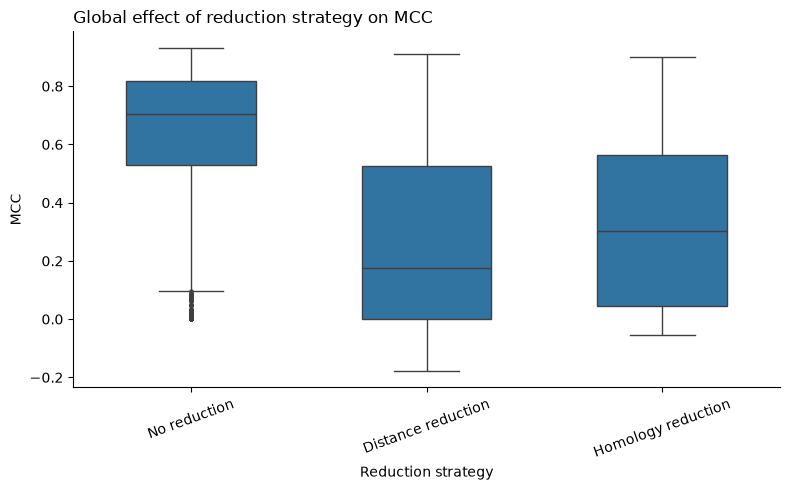

In [21]:
plot_reduction_effect_global(
    results,
    metric="f1_test_mean",
    ylabel="F1-score",
    title="Global effect of reduction strategy on F1-score"
)

plot_reduction_effect_global(
    results,
    metric="mcc_test_mean",
    ylabel="MCC",
    title="Global effect of reduction strategy on MCC"
)

- Extended Question 2: How does the percentile affect things?

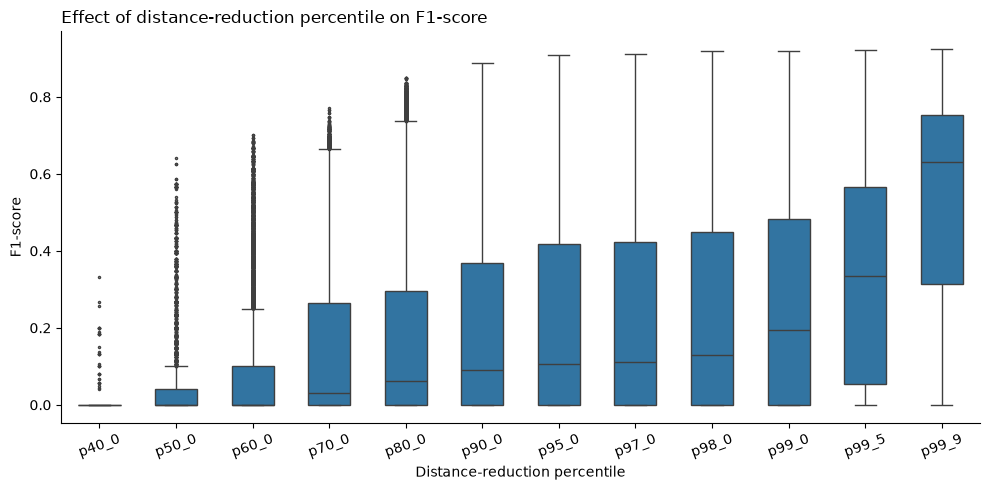

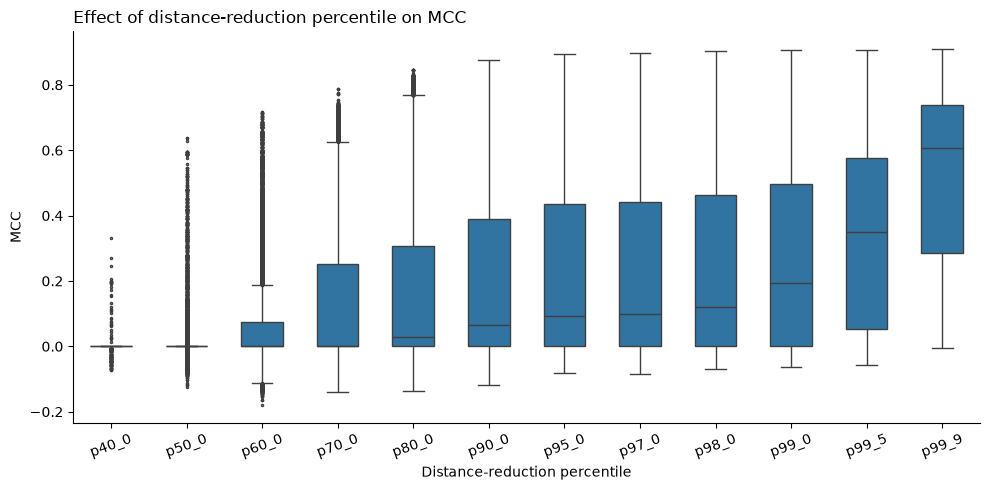

In [22]:
plot_distance_percentile_effect(
    results,
    metric="f1_test_mean",
    ylabel="F1-score",
    title="Effect of distance-reduction percentile on F1-score"
)

plot_distance_percentile_effect(
    results,
    metric="mcc_test_mean",
    ylabel="MCC",
    title="Effect of distance-reduction percentile on MCC"
)

- Extended Question 2: How does the threshold affect things?

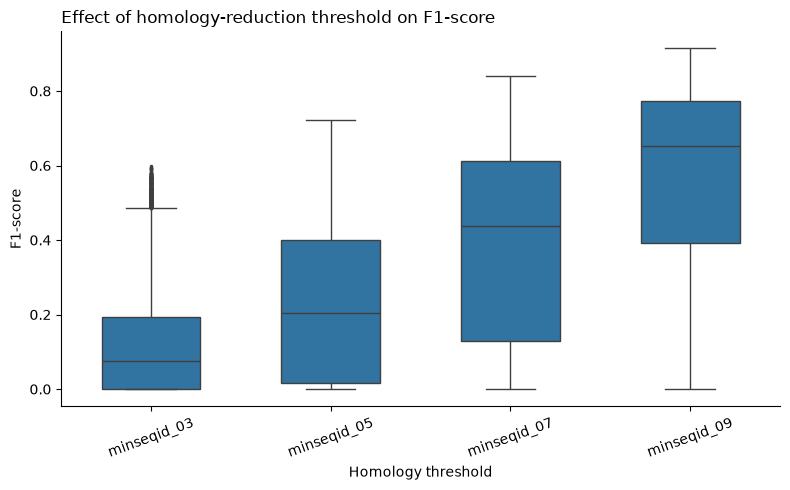

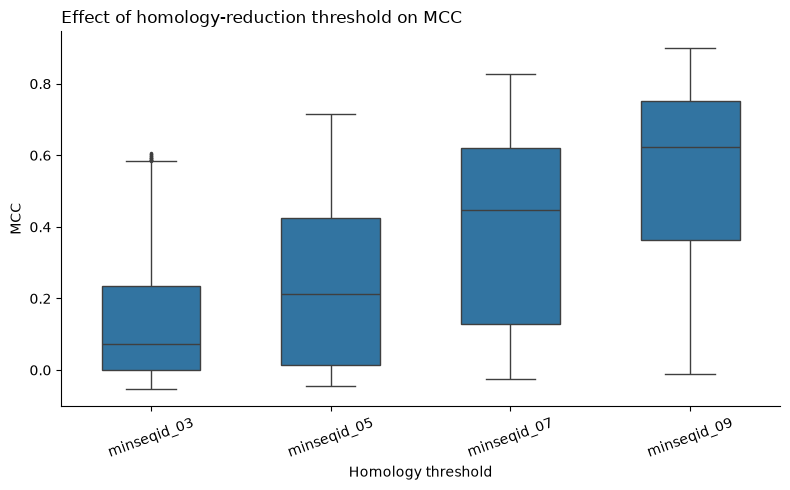

In [23]:
plot_homology_threshold_effect(
    results,
    metric="f1_test_mean",
    ylabel="F1-score",
    title="Effect of homology-reduction threshold on F1-score"
)

plot_homology_threshold_effect(
    results,
    metric="mcc_test_mean",
    ylabel="MCC",
    title="Effect of homology-reduction threshold on MCC"
)

- Question 3: How do the reduction × representation combinations affect the result?

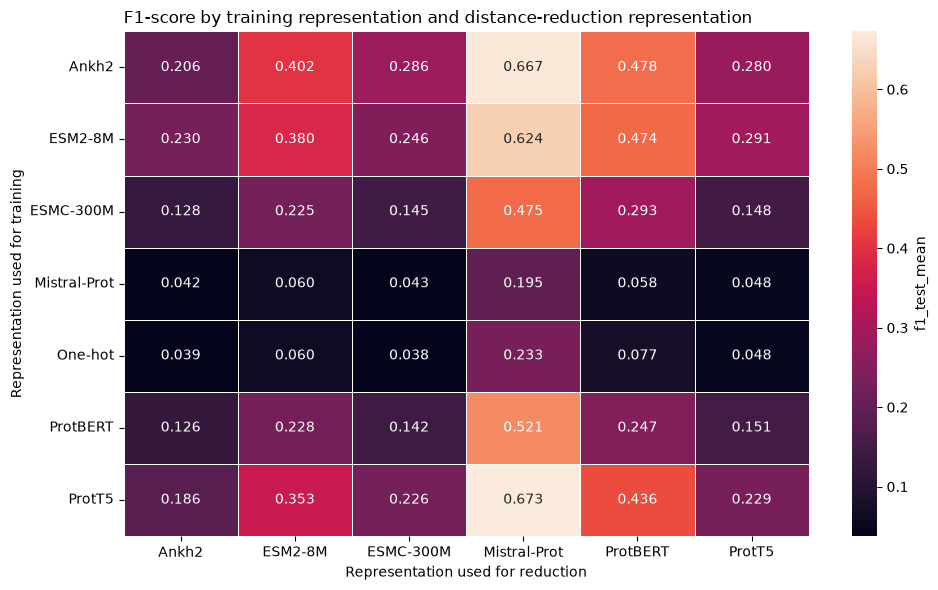

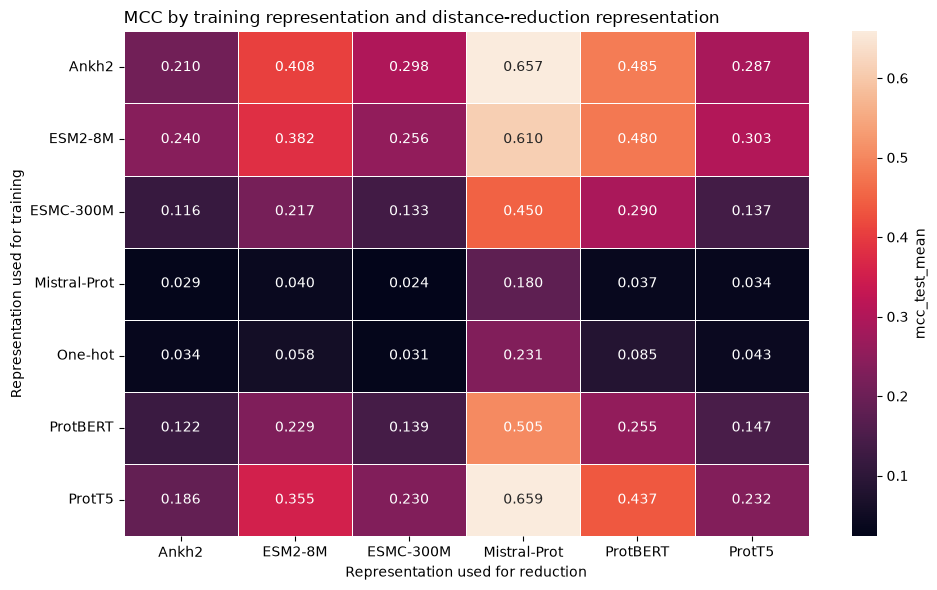

In [24]:
plot_representation_reducer_heatmap(
    results,
    metric="f1_test_mean",
    title="F1-score by training representation and distance-reduction representation"
)

plot_representation_reducer_heatmap(
    results,
    metric="mcc_test_mean",
    title="MCC by training representation and distance-reduction representation"
)

- Delta of reduction vs no reduction: How much does the yield change when I apply reduction compared to the same experiment without reduction?

In [25]:
delta_reduction_f1 = compute_reduction_delta(
    results,
    metric="f1_test_mean"
)

delta_reduction_mcc = compute_reduction_delta(
    results,
    metric="mcc_test_mean"
)

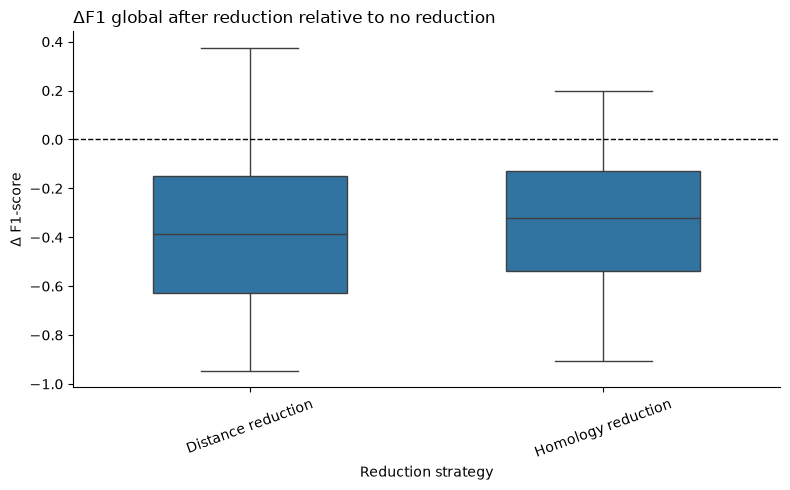

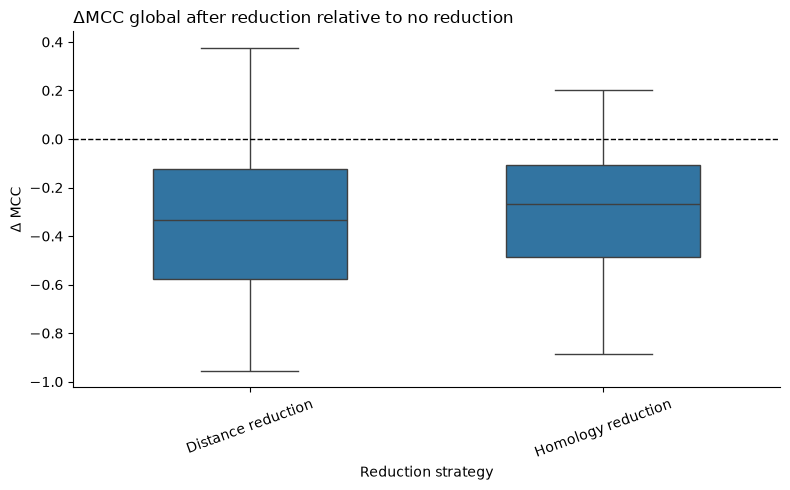

In [26]:
plot_reduction_delta(
    delta_reduction_f1,
    ylabel="Δ F1-score",
    title="ΔF1 global after reduction relative to no reduction"
)

plot_reduction_delta(
    delta_reduction_mcc,
    ylabel="Δ MCC",
    title="ΔMCC global after reduction relative to no reduction"
)

- Delta by combination representation × reduced_by

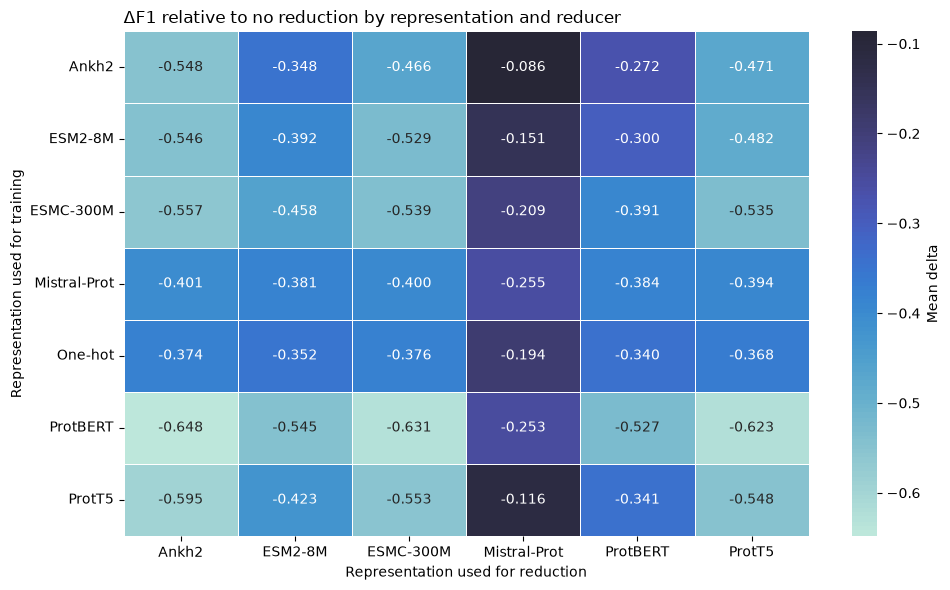

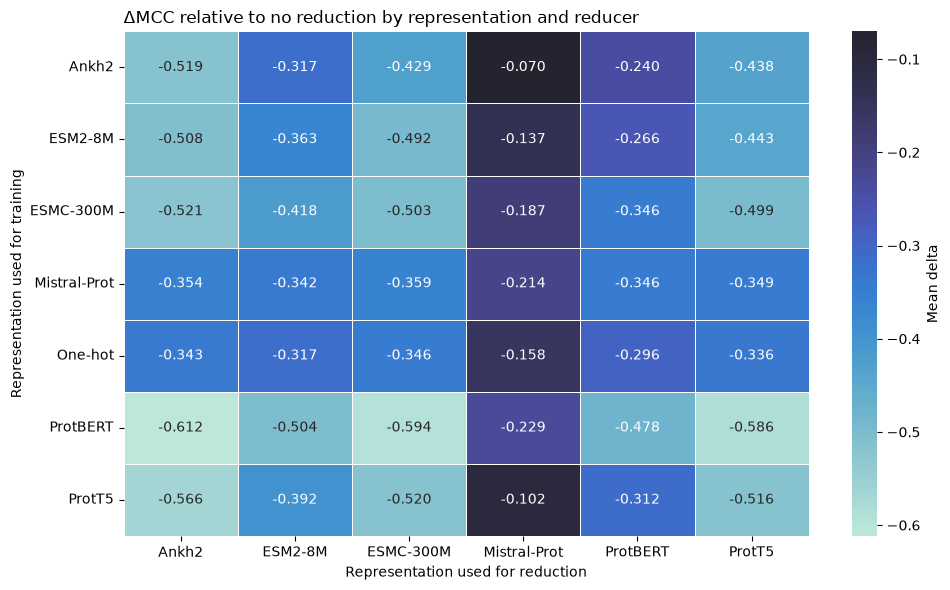

In [27]:
plot_reduction_delta_heatmap(
    delta_reduction_f1,
    title="ΔF1 relative to no reduction by representation and reducer"
)

plot_reduction_delta_heatmap(
    delta_reduction_mcc,
    title="ΔMCC relative to no reduction by representation and reducer"
)

- Partitioning Delta: What happens if I use Stratified or Distance-aware instead of Random, keeping everything else the same?

In [28]:
delta_partition_f1 = compute_partition_delta(
    results,
    metric="f1_test_mean",
    reference_partition="random_kfold"
)

delta_partition_mcc = compute_partition_delta(
    results,
    metric="mcc_test_mean",
    reference_partition="random_kfold"
)

delta_partition_f1_b1 = compute_partition_delta(
    b1,
    metric="f1_test_mean",
    reference_partition="random_kfold"
)

delta_partition_f1_b2 = compute_partition_delta(
    b2,
    metric="f1_test_mean",
    reference_partition="random_kfold"
)

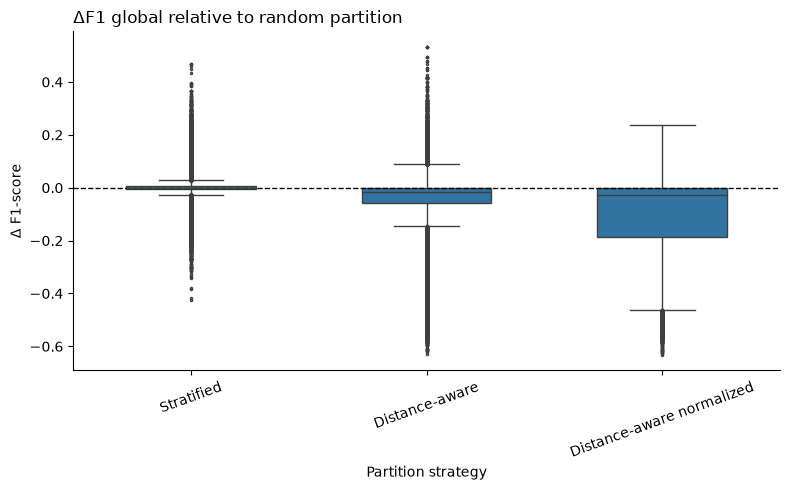

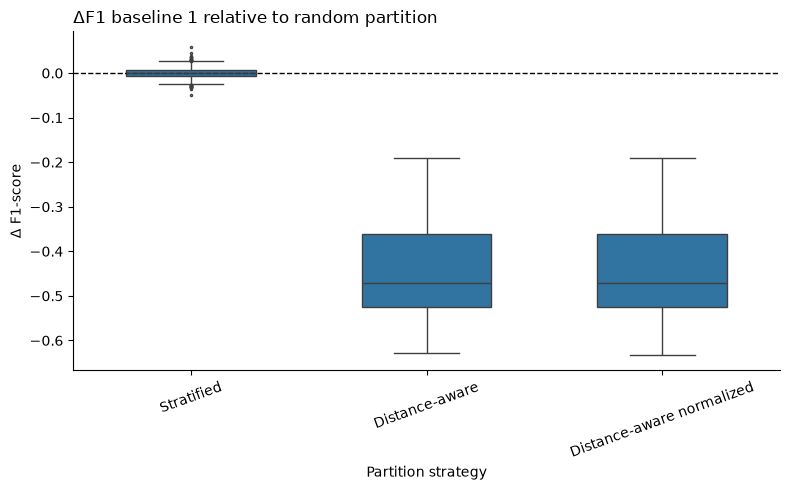

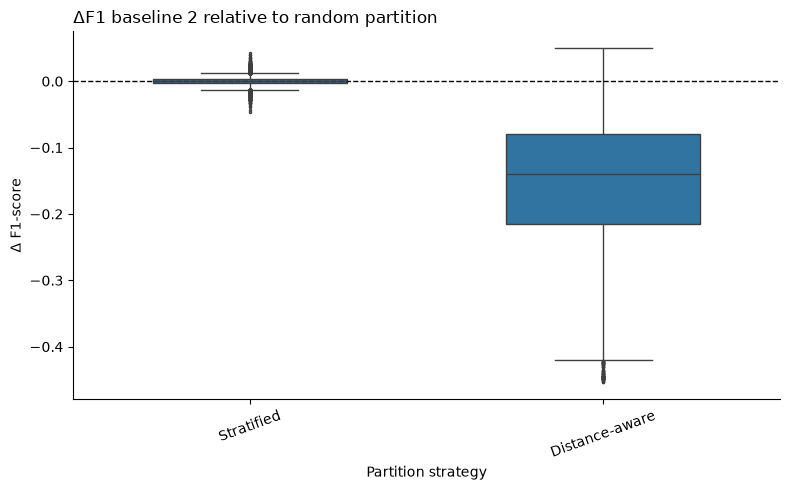

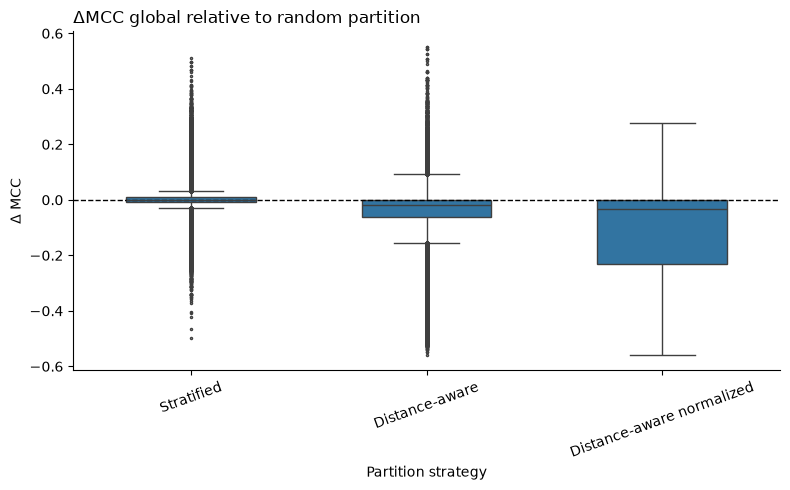

In [29]:
plot_partition_delta(
    delta_partition_f1,
    ylabel="Δ F1-score",
    title="ΔF1 global relative to random partition"
)

plot_partition_delta(
    delta_partition_f1_b1,
    ylabel="Δ F1-score",
    title="ΔF1 baseline 1 relative to random partition"
)

plot_partition_delta(
    delta_partition_f1_b2,
    ylabel="Δ F1-score",
    title="ΔF1 baseline 2 relative to random partition"
)

plot_partition_delta(
    delta_partition_mcc,
    ylabel="Δ MCC",
    title="ΔMCC global relative to random partition"
)

- Question 4: combinations of partitioning + reduction + representation

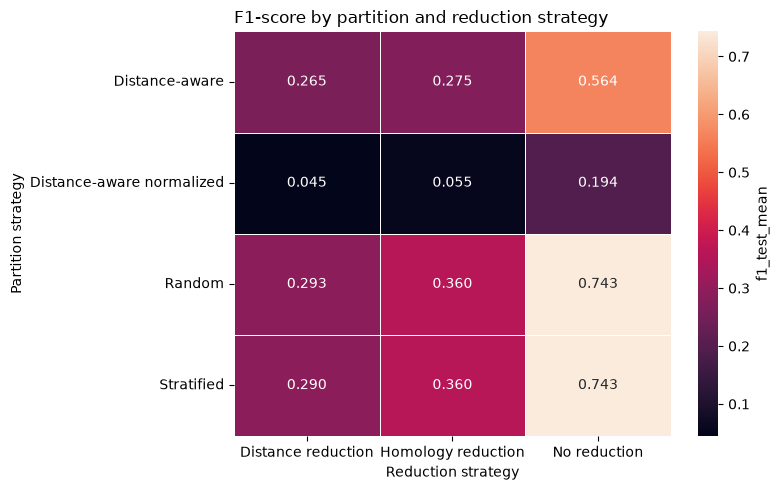

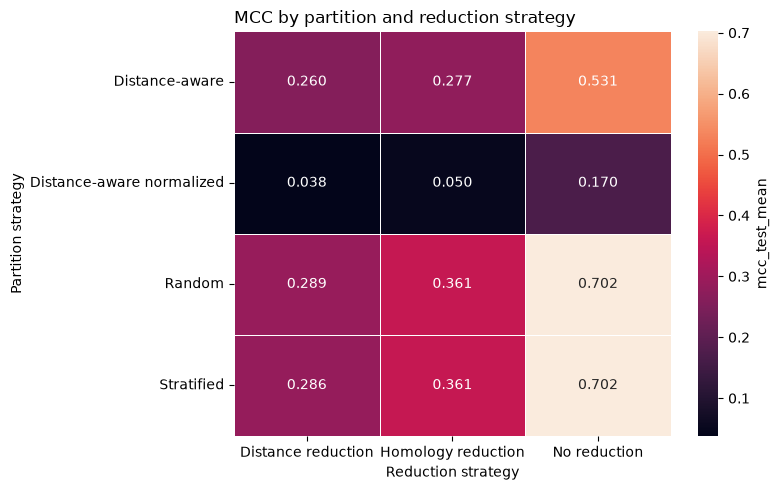

In [30]:
plot_partition_reduction_heatmap(
    results,
    metric="f1_test_mean",
    title="F1-score by partition and reduction strategy"
)

plot_partition_reduction_heatmap(
    results,
    metric="mcc_test_mean",
    title="MCC by partition and reduction strategy"
)

- How does partitioning/reduction/percentile affect each representation?

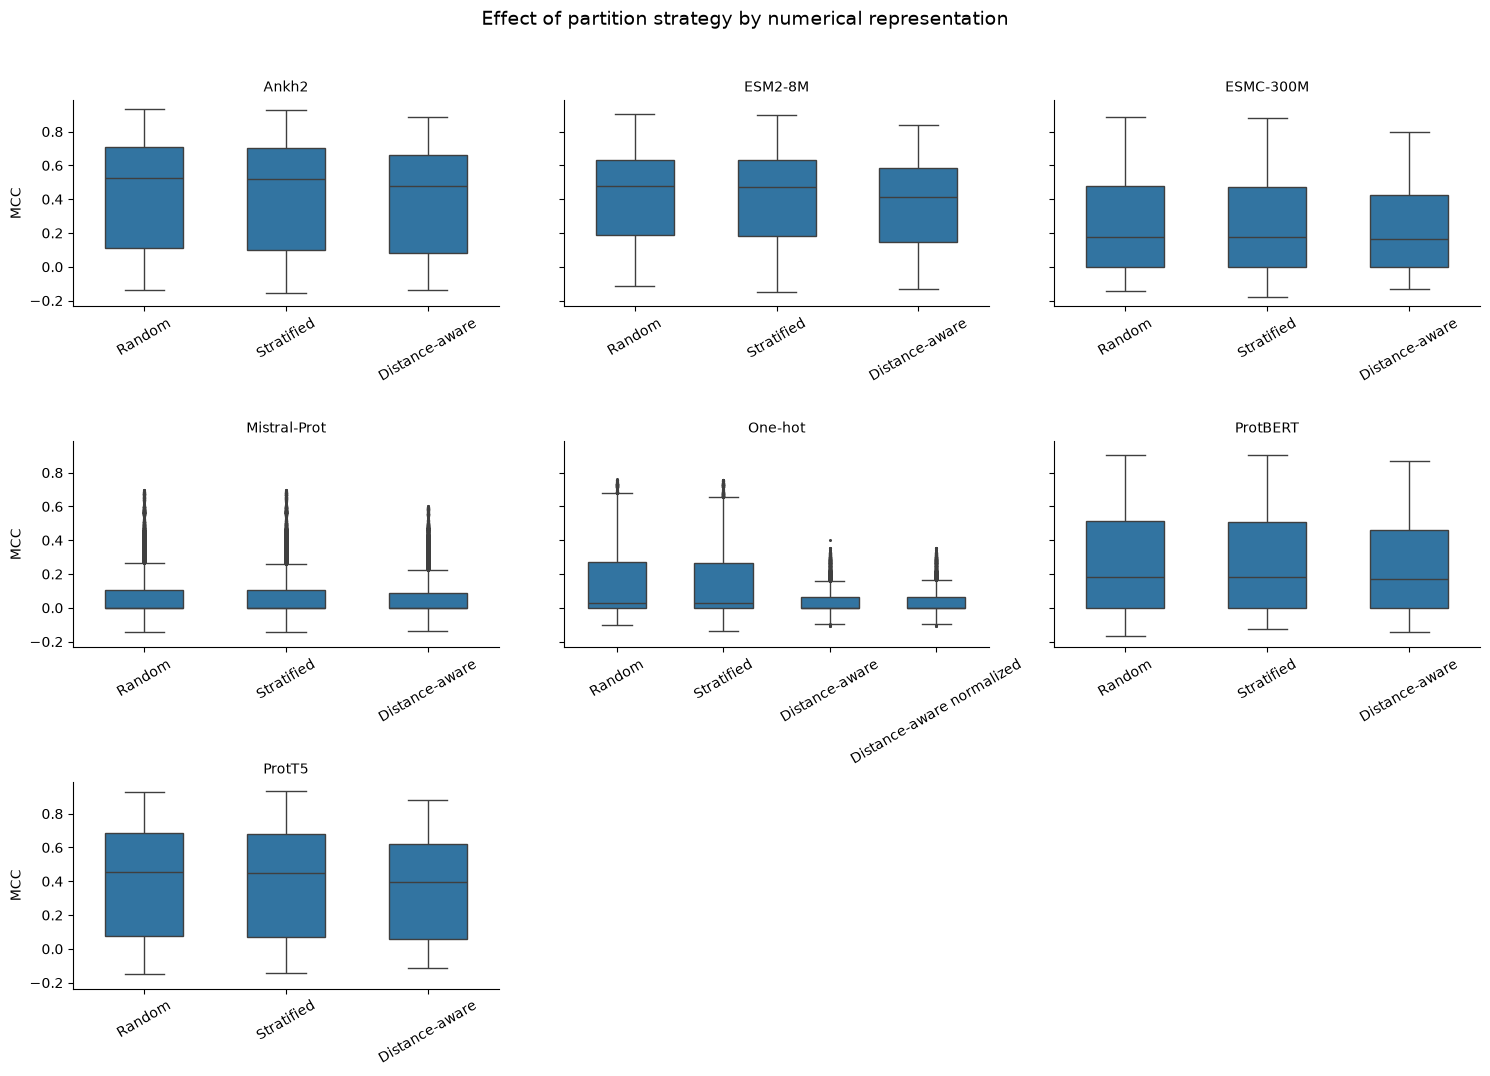

In [31]:
facet_boxplot_by_representation(
    results,
    x_col="partition_label",
    y_col="mcc_test_mean",
    x_order=["Random", "Stratified", "Distance-aware", "Distance-aware normalized"],
    title="Effect of partition strategy by numerical representation",
    ylabel="MCC",
    xlabel="Partition strategy"
)

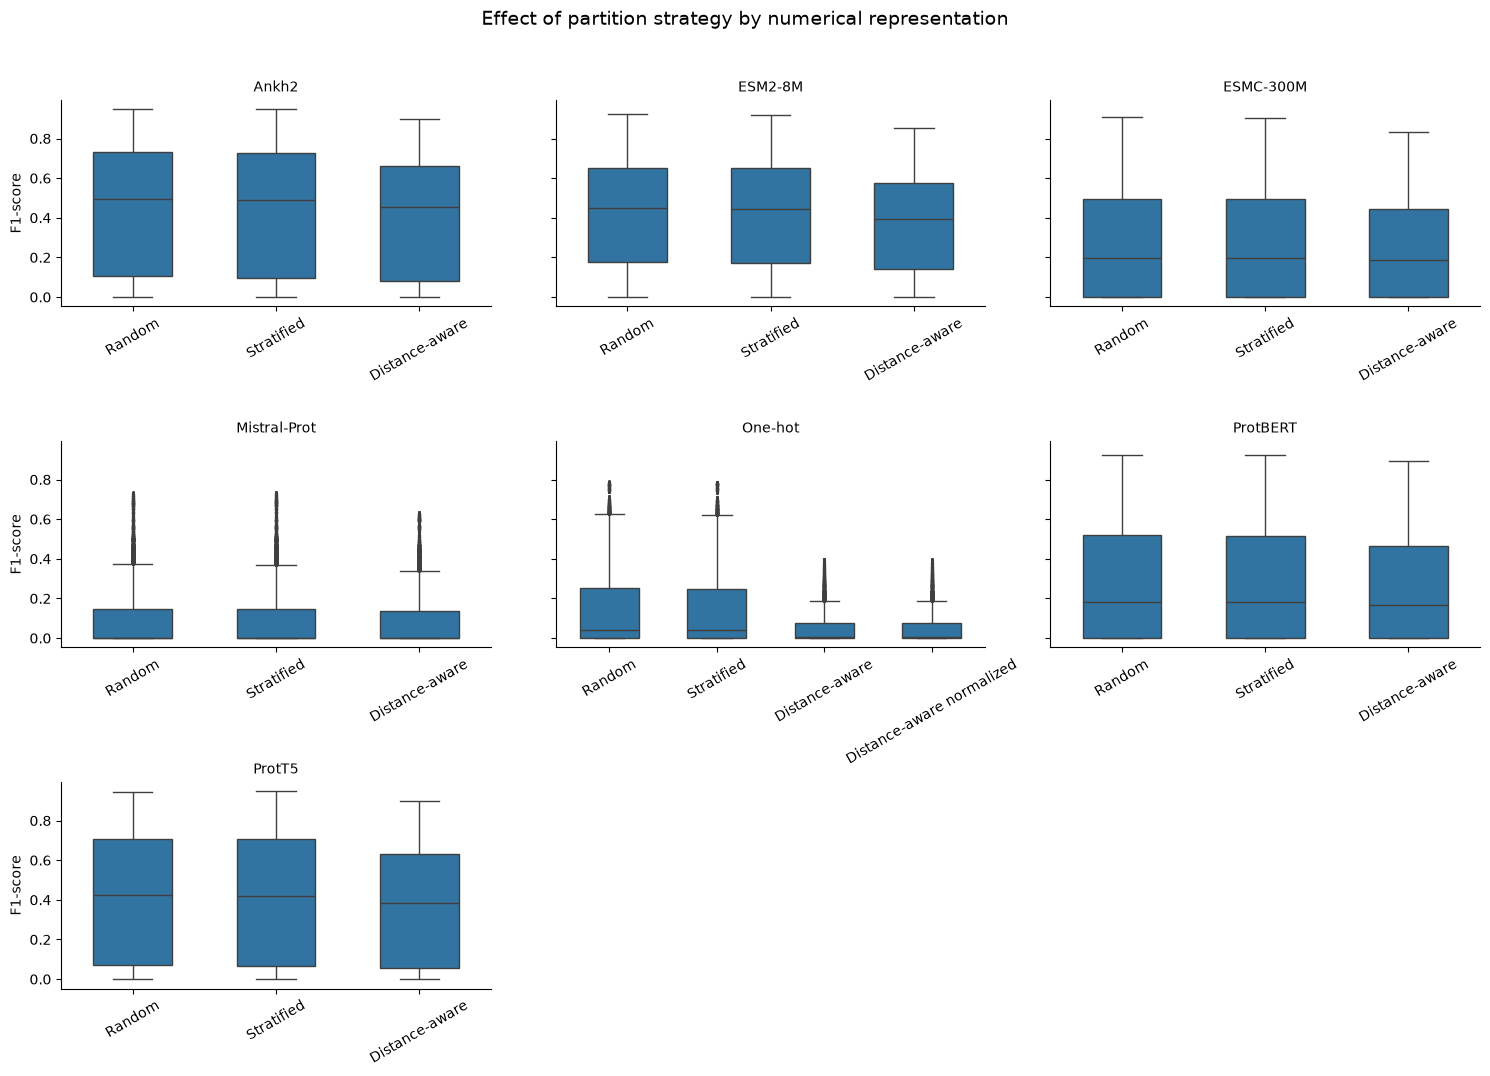

In [32]:
facet_boxplot_by_representation(
    results,
    x_col="partition_label",
    y_col="f1_test_mean",
    x_order=["Random", "Stratified", "Distance-aware", "Distance-aware normalized"],
    title="Effect of partition strategy by numerical representation",
    ylabel="F1-score",
    xlabel="Partition strategy"
)

- Reduction for representation

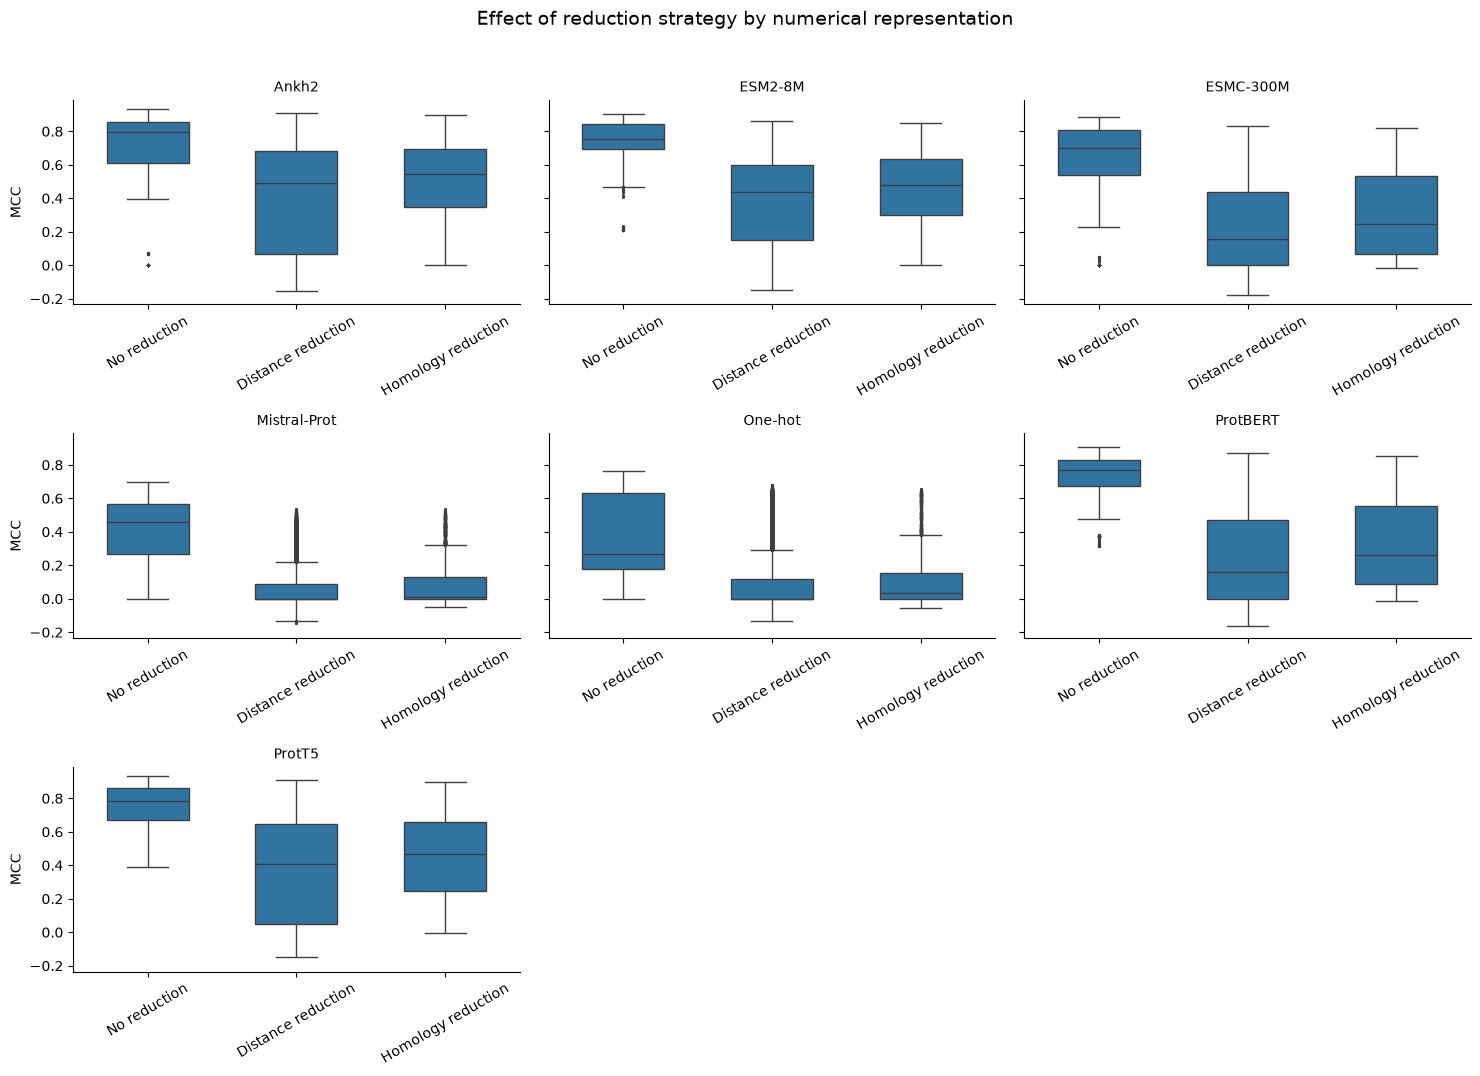

In [33]:
facet_boxplot_by_representation(
    results,
    x_col="reduction_label",
    y_col="mcc_test_mean",
    x_order=["No reduction", "Distance reduction", "Homology reduction"],
    title="Effect of reduction strategy by numerical representation",
    ylabel="MCC",
    xlabel="Reduction strategy"
)

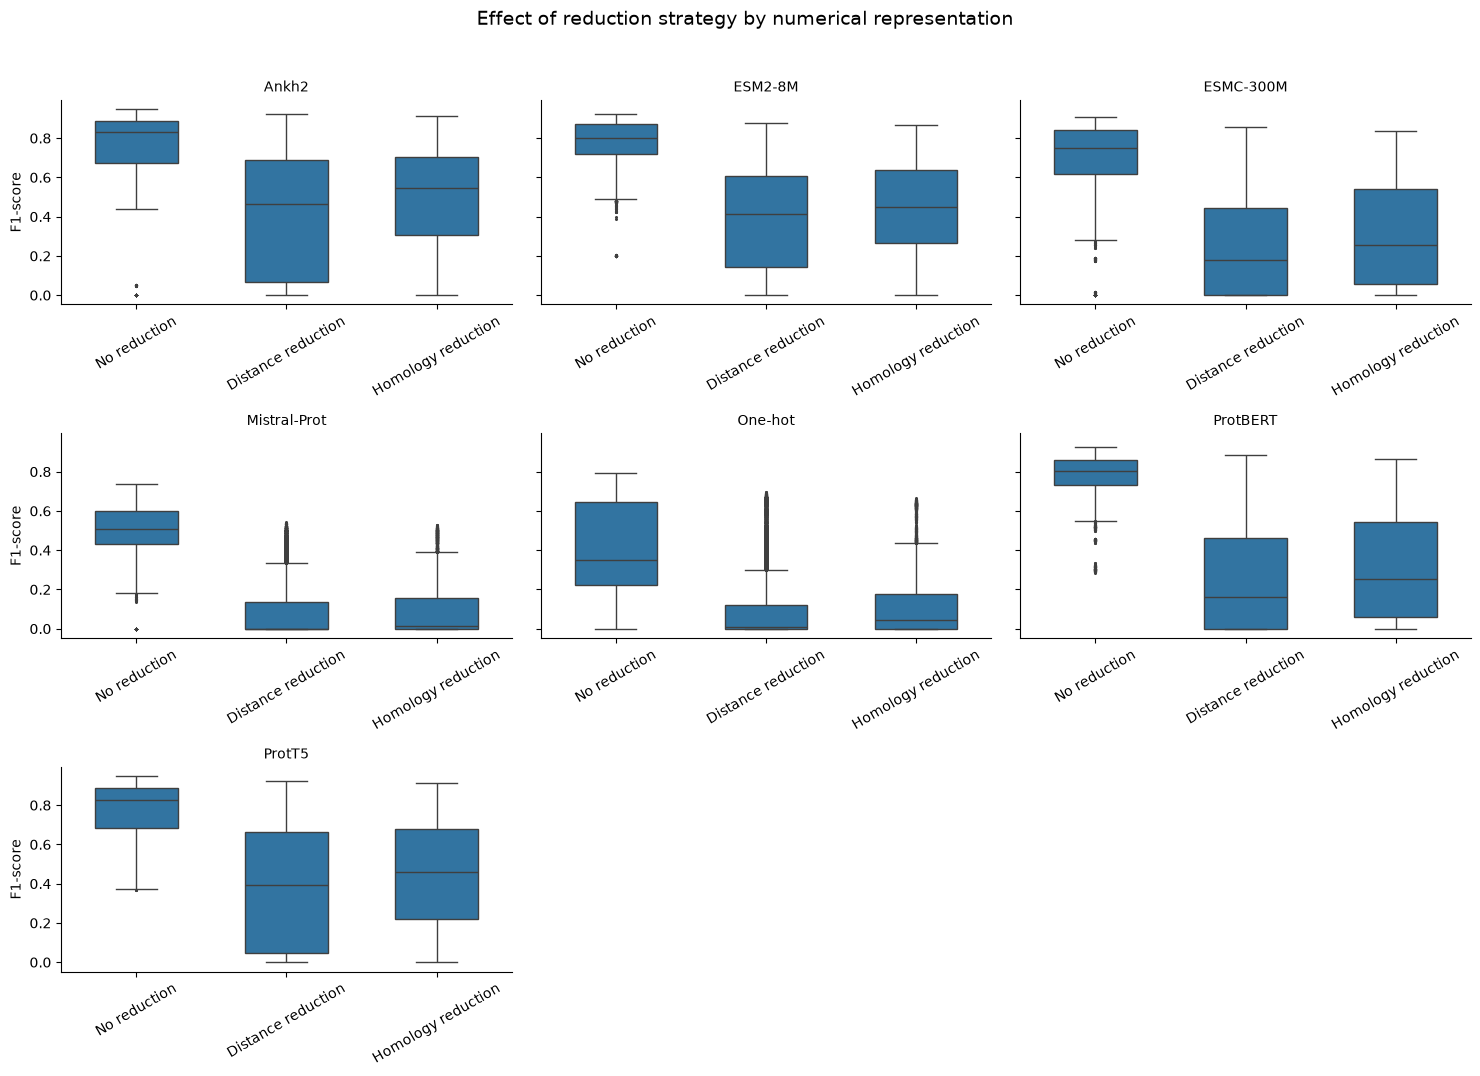

In [34]:
facet_boxplot_by_representation(
    results,
    x_col="reduction_label",
    y_col="f1_test_mean",
    x_order=["No reduction", "Distance reduction", "Homology reduction"],
    title="Effect of reduction strategy by numerical representation",
    ylabel="F1-score",
    xlabel="Reduction strategy"
)

- Percentile by representation

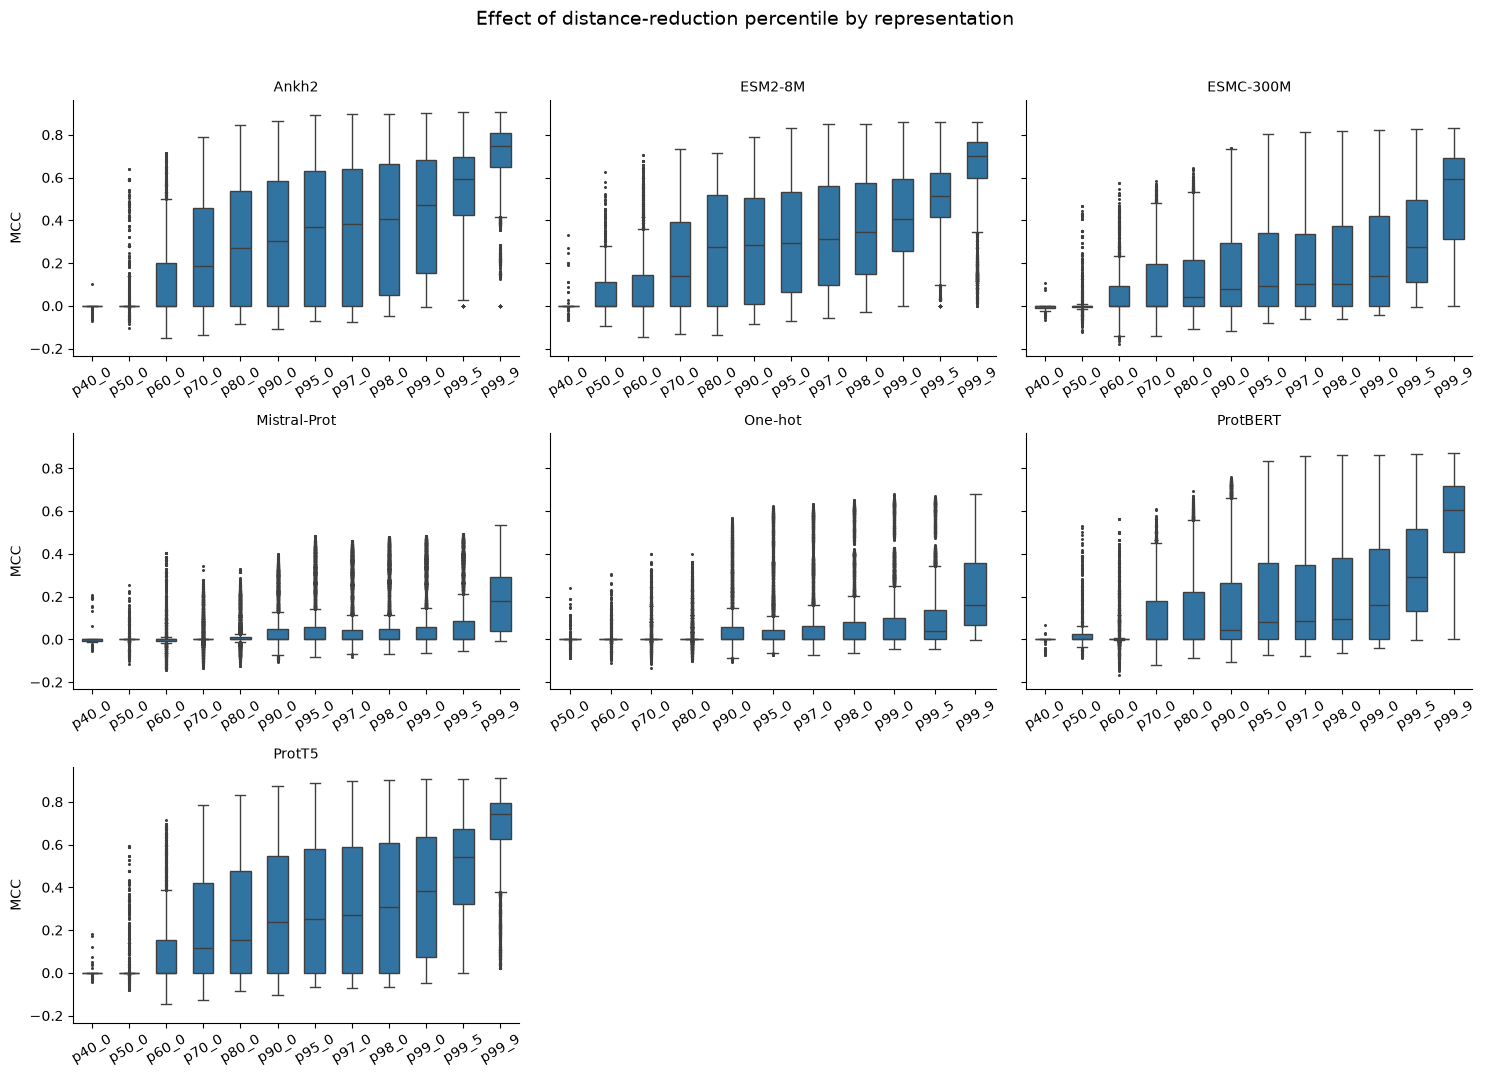

In [35]:
distance_results = results[
    results["reduction_strategy_clean"] == "distance_reduction"
].copy()

distance_results = distance_results[
    distance_results["reduction_percentile"] != "not_applicable"
].copy()

percentile_order = sort_percentile_levels(
    distance_results["reduction_percentile"].unique()
)

facet_boxplot_by_representation(
    distance_results,
    x_col="reduction_percentile",
    y_col="mcc_test_mean",
    x_order=percentile_order,
    title="Effect of distance-reduction percentile by representation",
    ylabel="MCC",
    xlabel="Distance-reduction percentile"
)

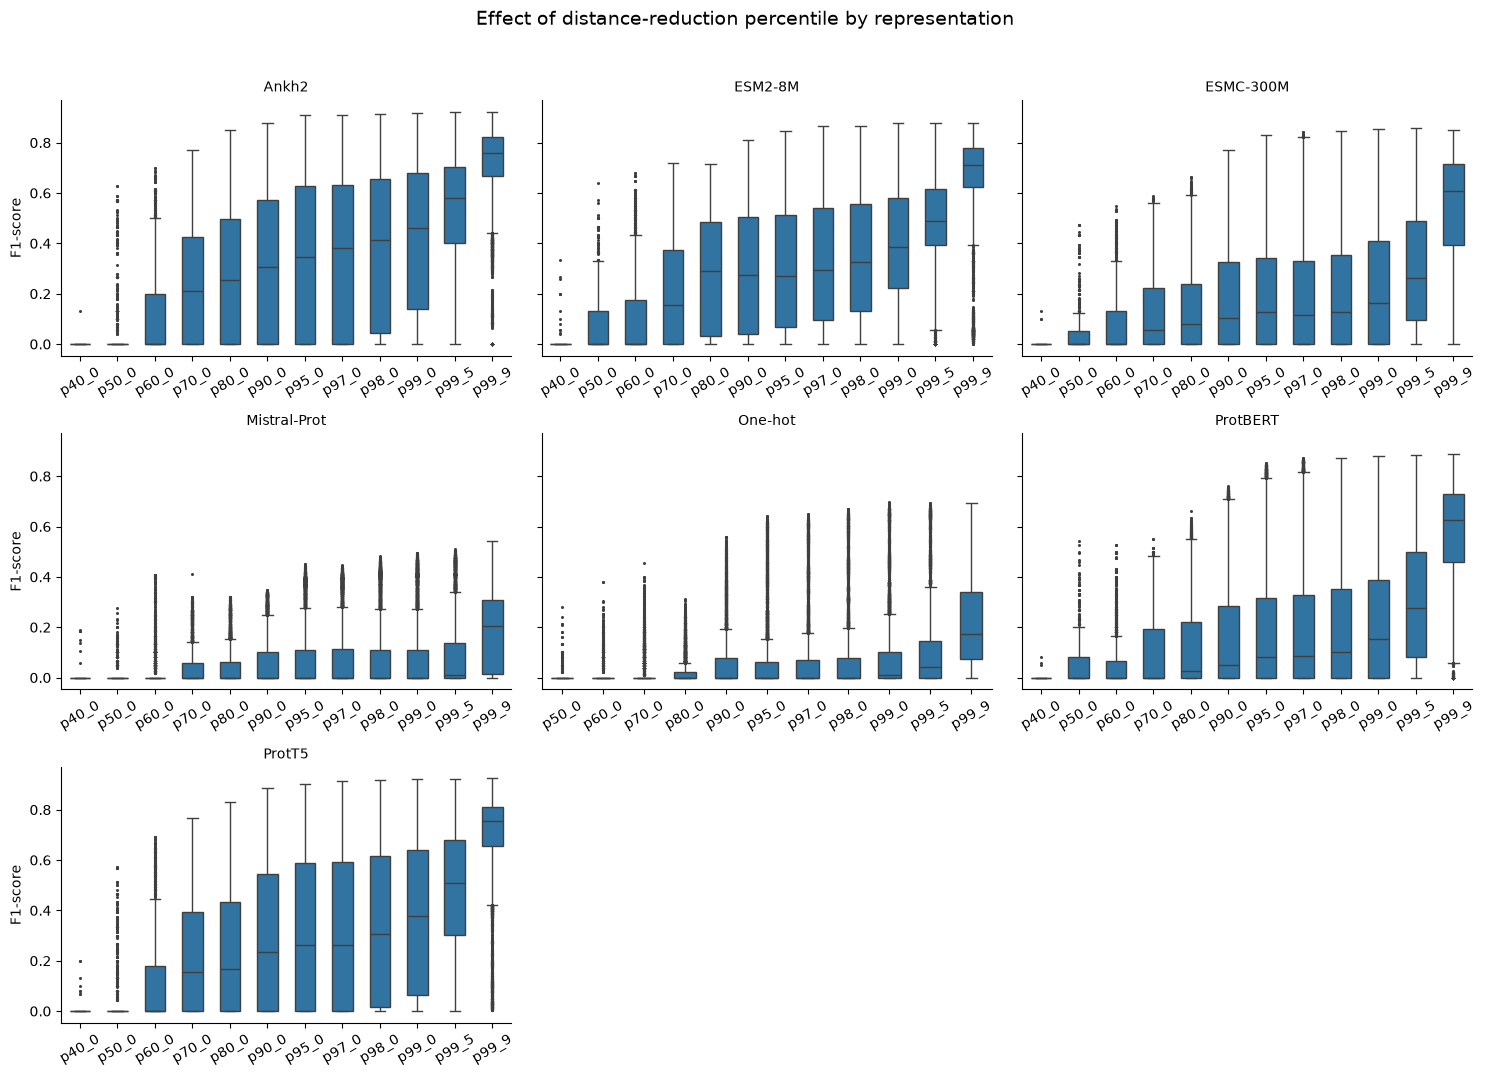

In [36]:
facet_boxplot_by_representation(
    distance_results,
    x_col="reduction_percentile",
    y_col="f1_test_mean",
    x_order=percentile_order,
    title="Effect of distance-reduction percentile by representation",
    ylabel="F1-score",
    xlabel="Distance-reduction percentile"
)

- General function for boxplots by algorithm: Which algorithms are most sensitive to partitioning, reduction, or percentile?

- Partitioning by algorithm

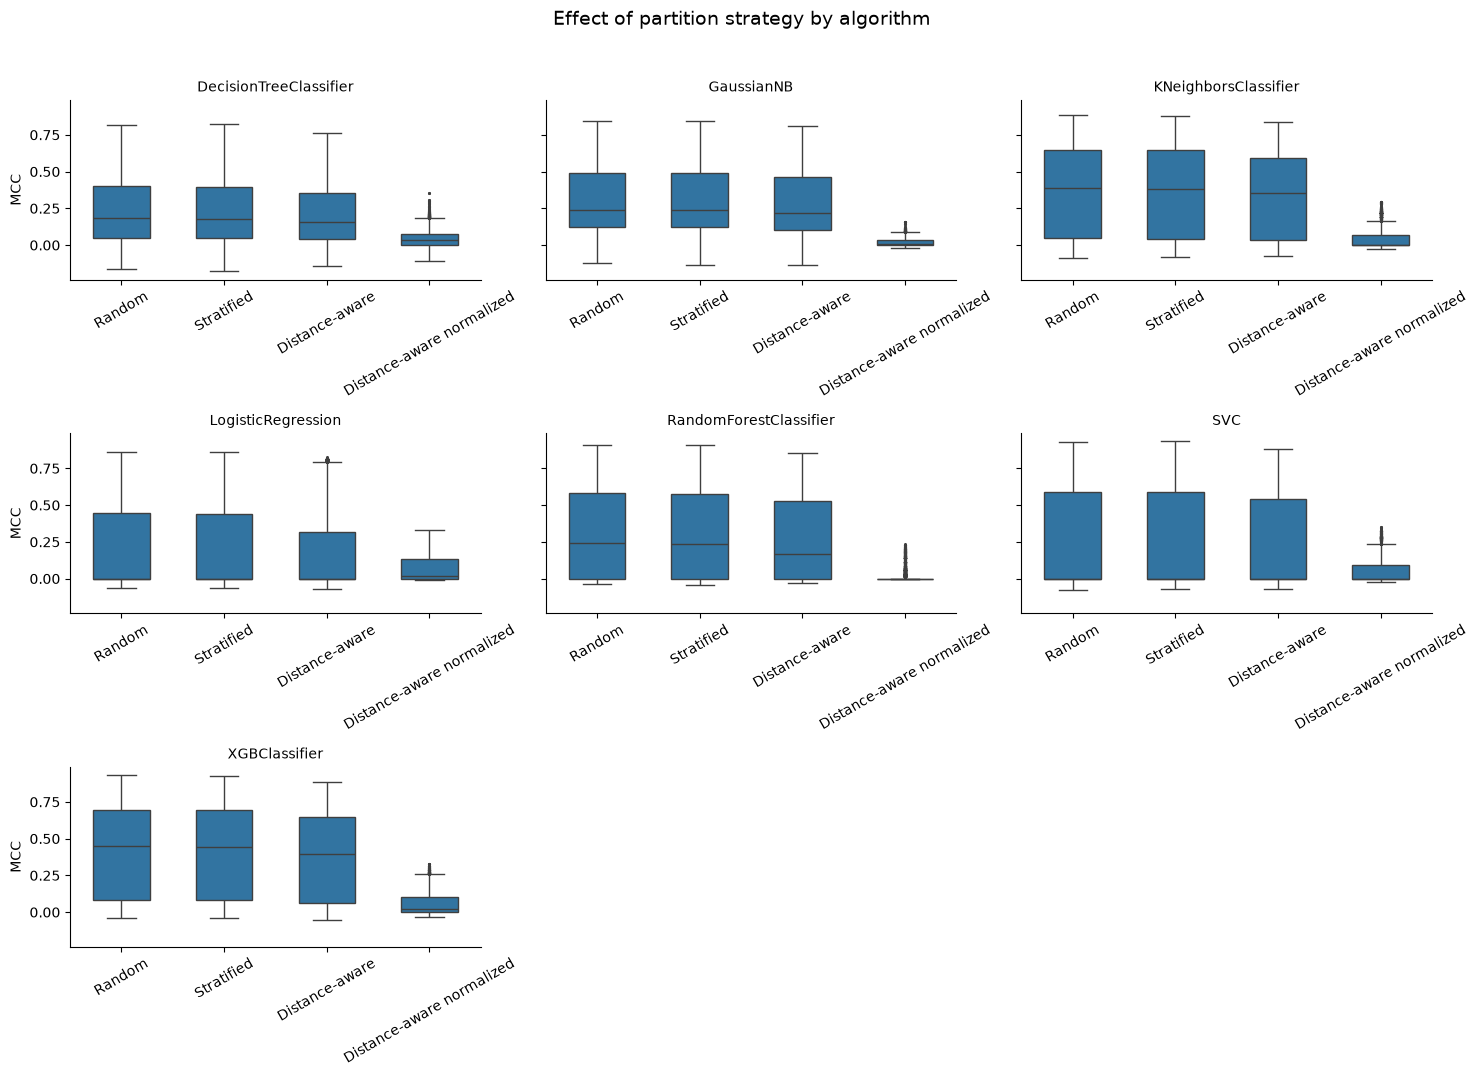

In [37]:
facet_boxplot_by_algorithm(
    results,
    x_col="partition_label",
    y_col="mcc_test_mean",
    x_order=["Random", "Stratified", "Distance-aware", "Distance-aware normalized"],
    title="Effect of partition strategy by algorithm",
    ylabel="MCC",
    xlabel="Partition strategy"
)

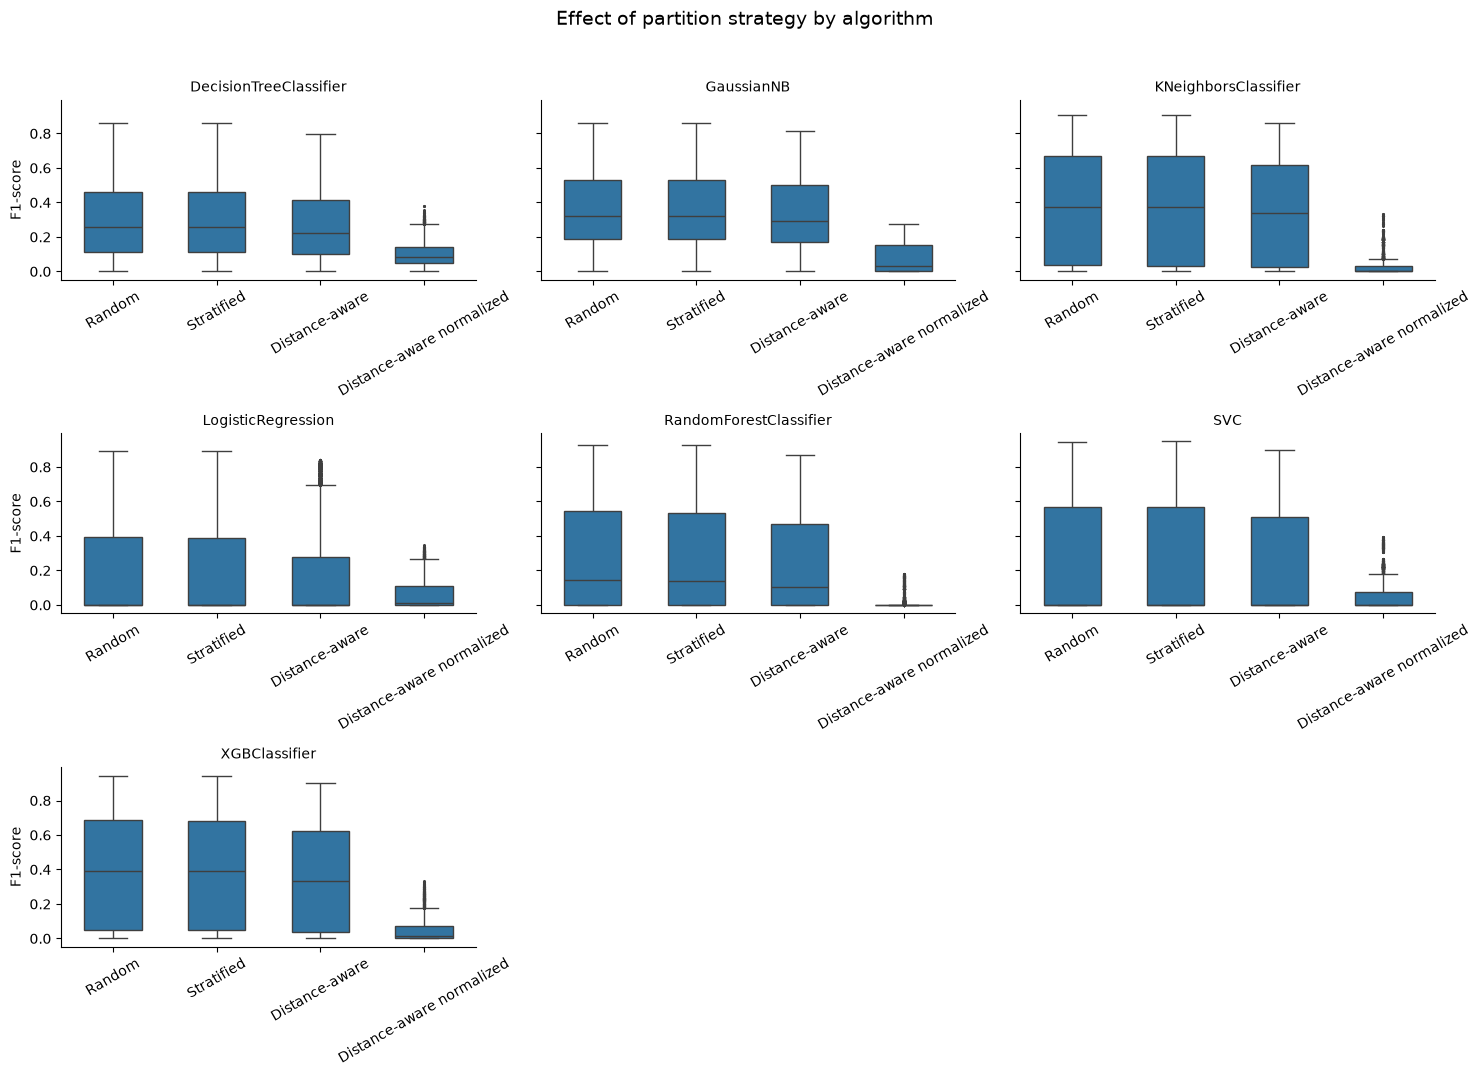

In [38]:
facet_boxplot_by_algorithm(
    results,
    x_col="partition_label",
    y_col="f1_test_mean",
    x_order=["Random", "Stratified", "Distance-aware", "Distance-aware normalized"],
    title="Effect of partition strategy by algorithm",
    ylabel="F1-score",
    xlabel="Partition strategy"
)

- Reduction by algorithm

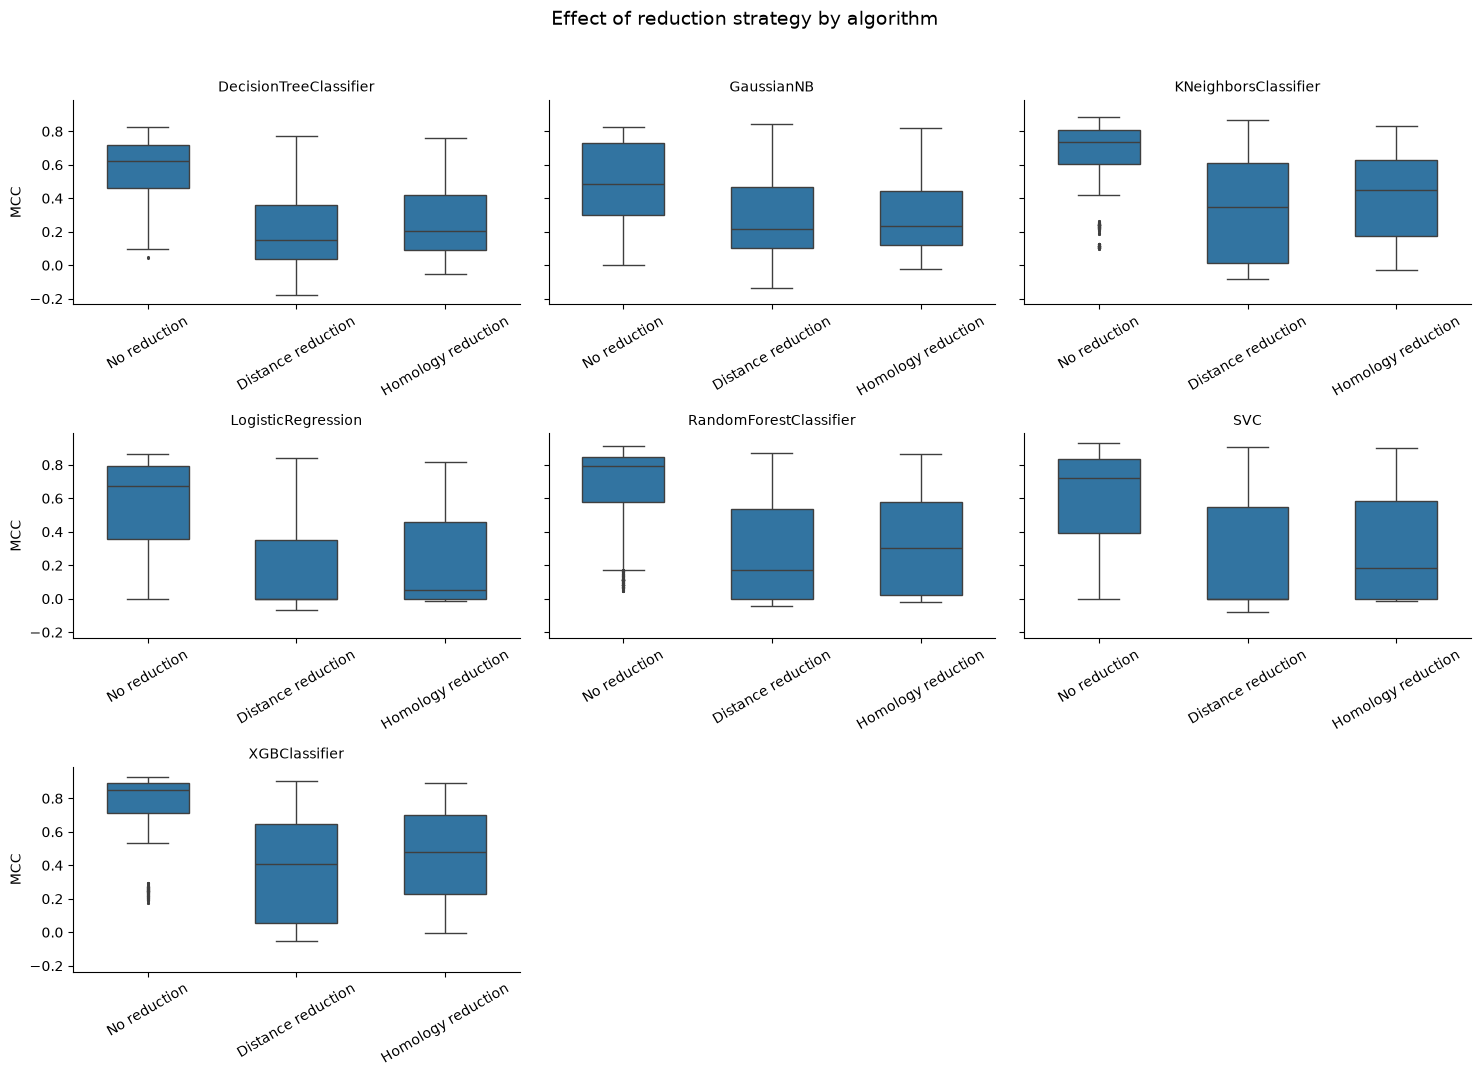

In [39]:
facet_boxplot_by_algorithm(
    results,
    x_col="reduction_label",
    y_col="mcc_test_mean",
    x_order=["No reduction", "Distance reduction", "Homology reduction"],
    title="Effect of reduction strategy by algorithm",
    ylabel="MCC",
    xlabel="Reduction strategy"
)

- Heatmap representation × algorithm

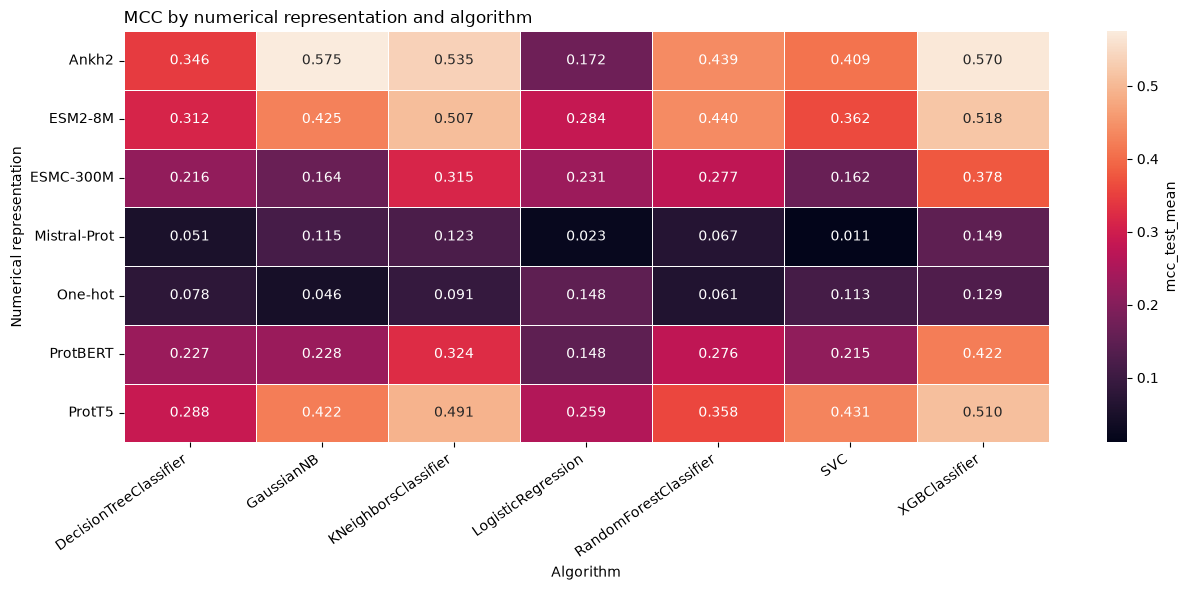

In [40]:
plot_representation_algorithm_heatmap(
    results,
    metric="mcc_test_mean",
    title="MCC by numerical representation and algorithm"
)

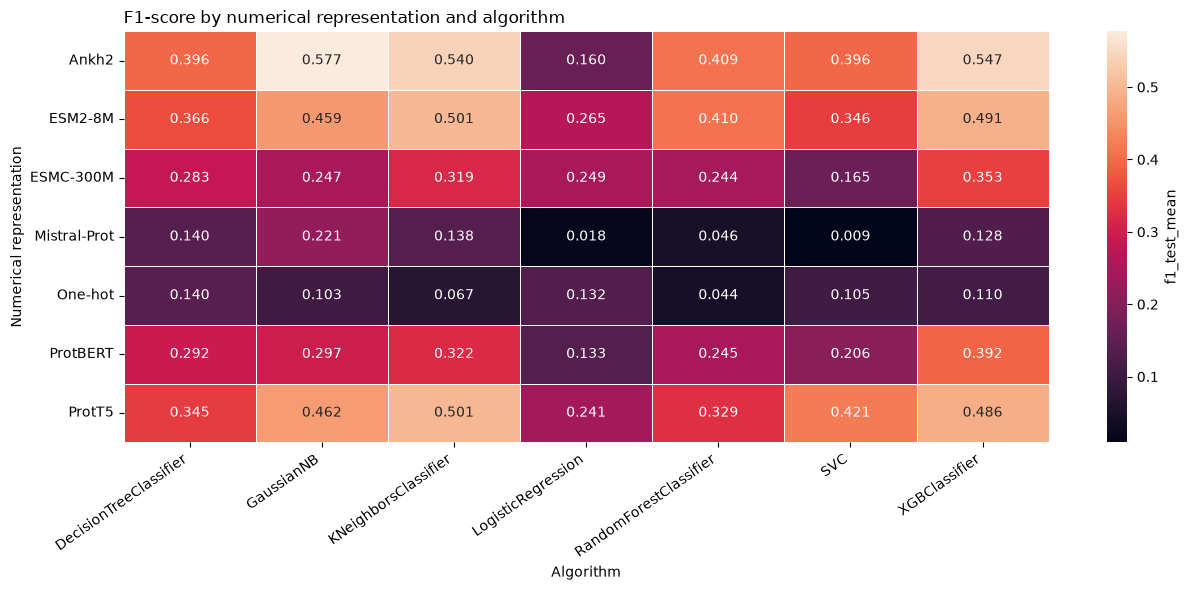

In [41]:
plot_representation_algorithm_heatmap(
    results,
    metric="f1_test_mean",
    title="F1-score by numerical representation and algorithm"
)

- Heatmap partition × algorithm: Which algorithms drop the most when the partition changes?

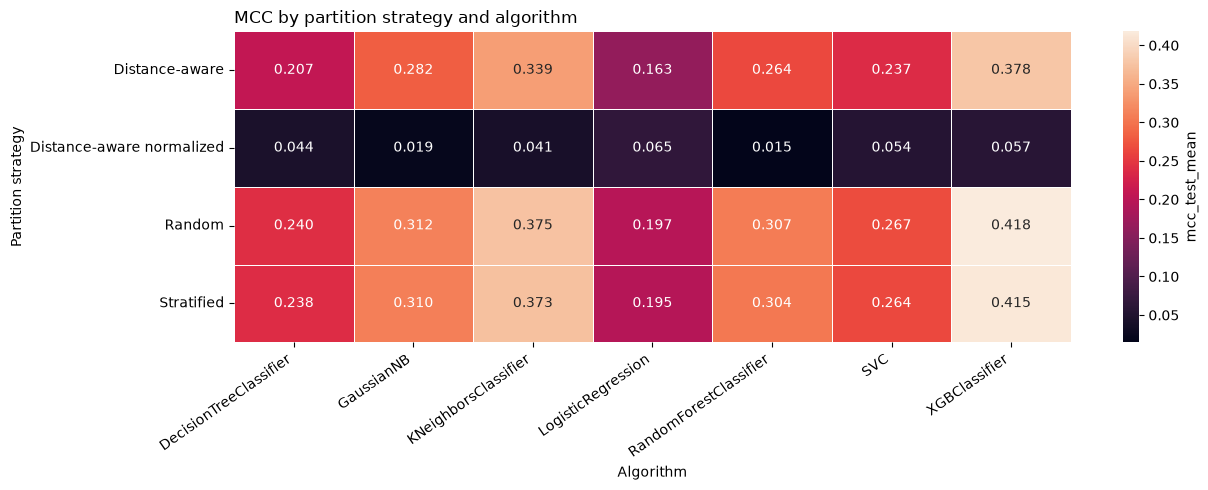

In [42]:
plot_partition_algorithm_heatmap(
    results,
    metric="mcc_test_mean",
    title="MCC by partition strategy and algorithm"
)

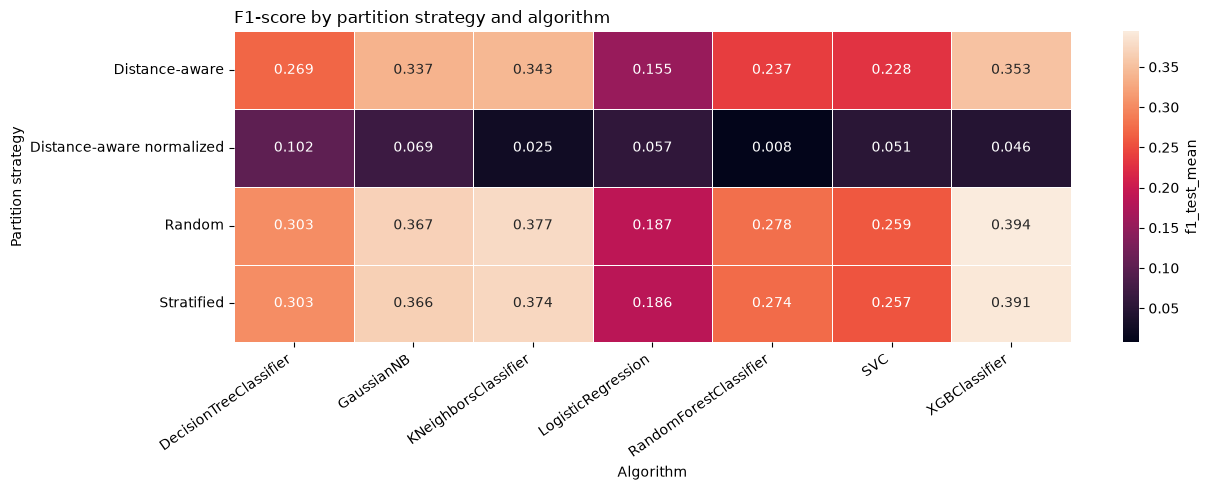

In [43]:
plot_partition_algorithm_heatmap(
    results,
    metric="f1_test_mean",
    title="F1-score by partition strategy and algorithm"
)

- Heatmap reduction algorithm

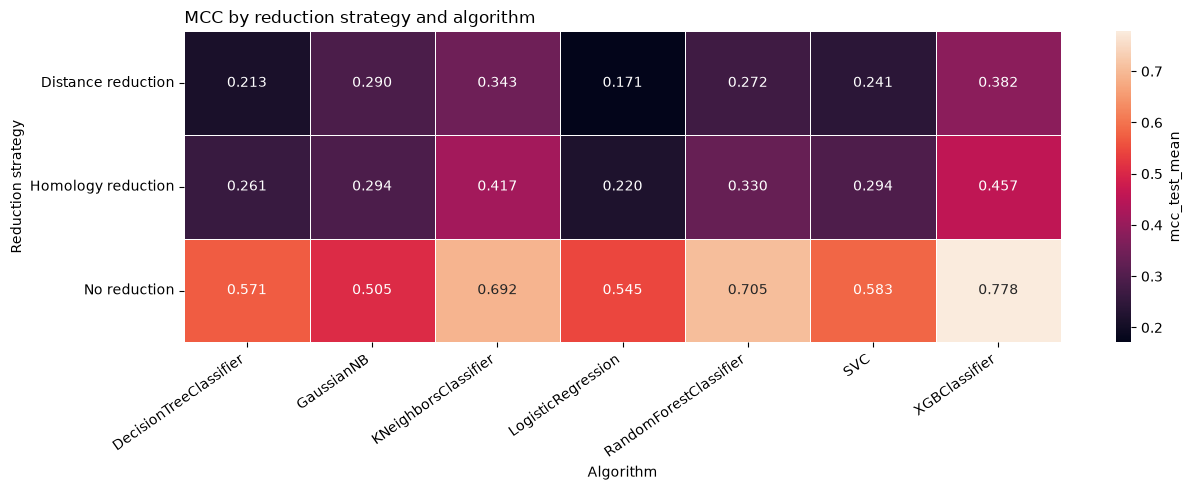

In [44]:
plot_reduction_algorithm_heatmap(
    results,
    metric="mcc_test_mean",
    title="MCC by reduction strategy and algorithm"
)

- Deltas due to representation

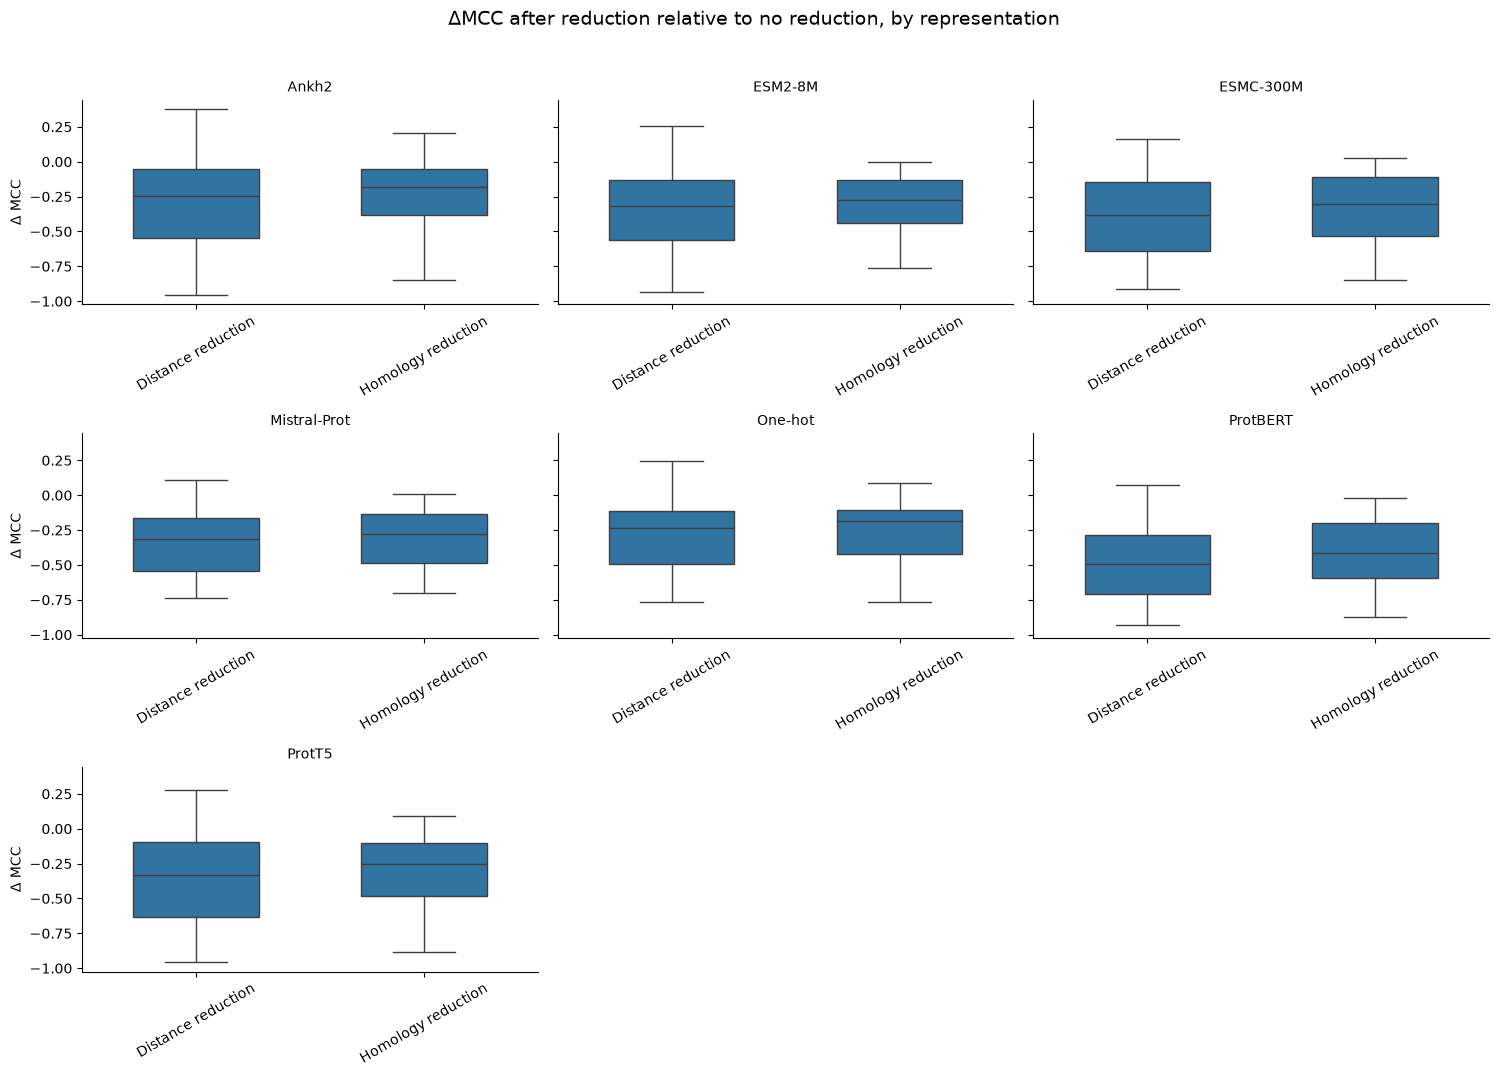

In [45]:
plot_reduction_delta_by_representation(
    delta_reduction_mcc,
    ylabel="Δ MCC",
    title="ΔMCC after reduction relative to no reduction, by representation"
)

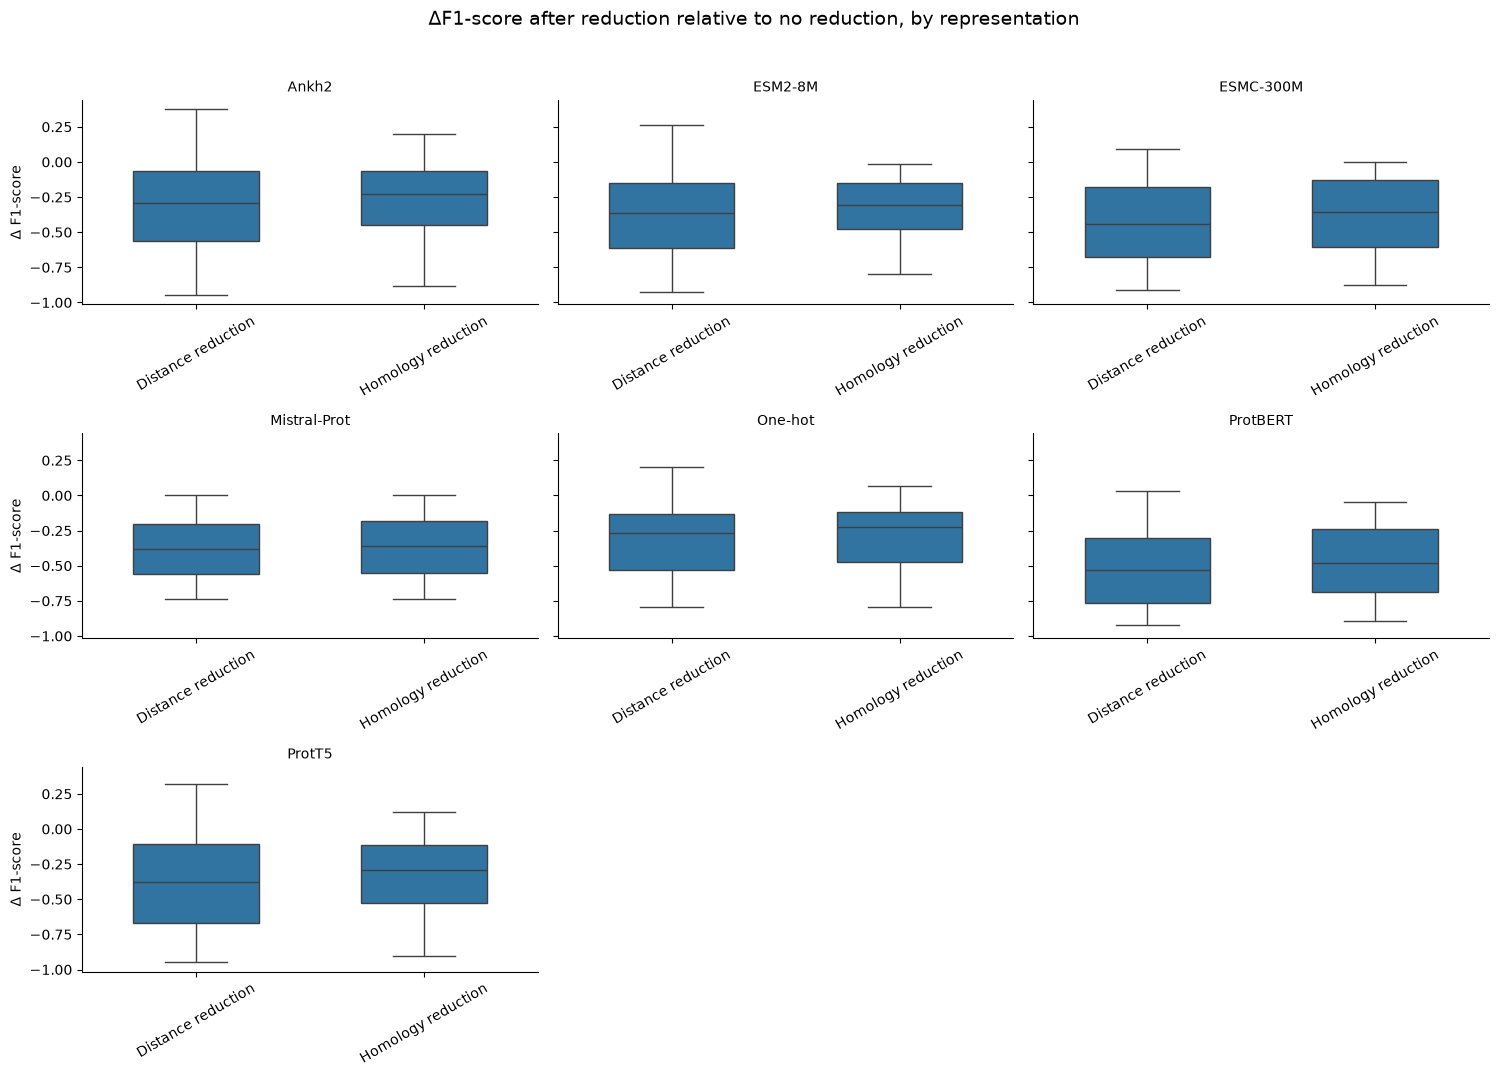

In [46]:
plot_reduction_delta_by_representation(
    delta_reduction_f1,
    ylabel="Δ F1-score",
    title="ΔF1-score after reduction relative to no reduction, by representation"
)

- Deltas by algorithms

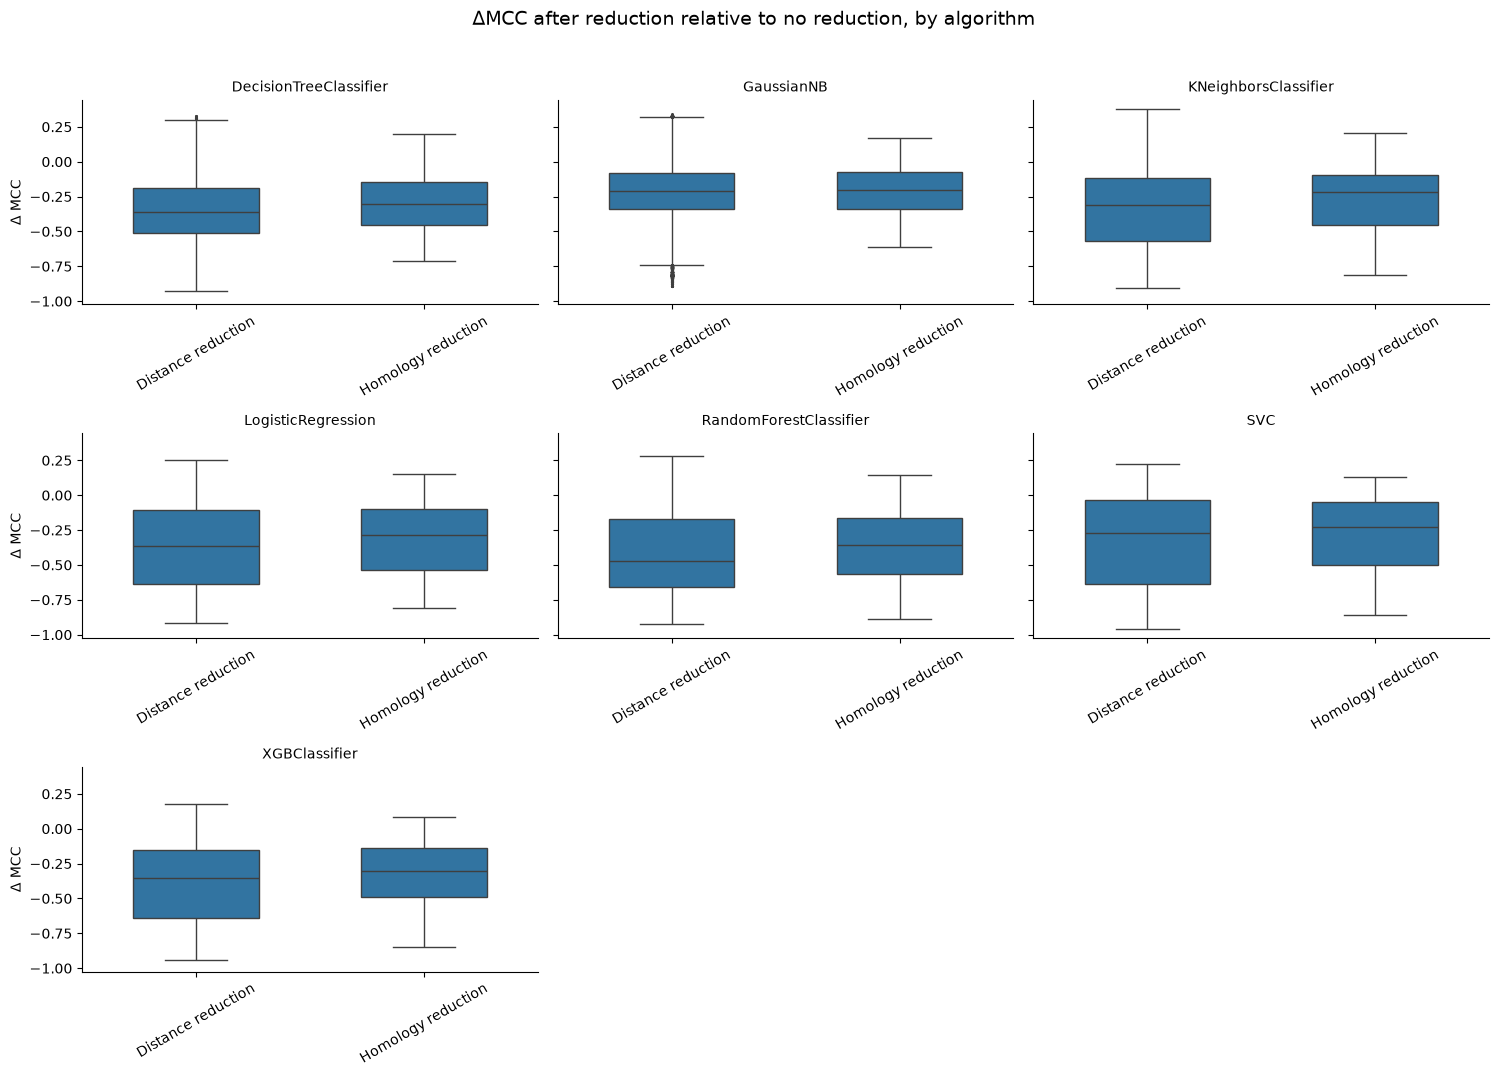

In [47]:
plot_reduction_delta_by_algorithm(
    delta_reduction_mcc,
    ylabel="Δ MCC",
    title="ΔMCC after reduction relative to no reduction, by algorithm"
)

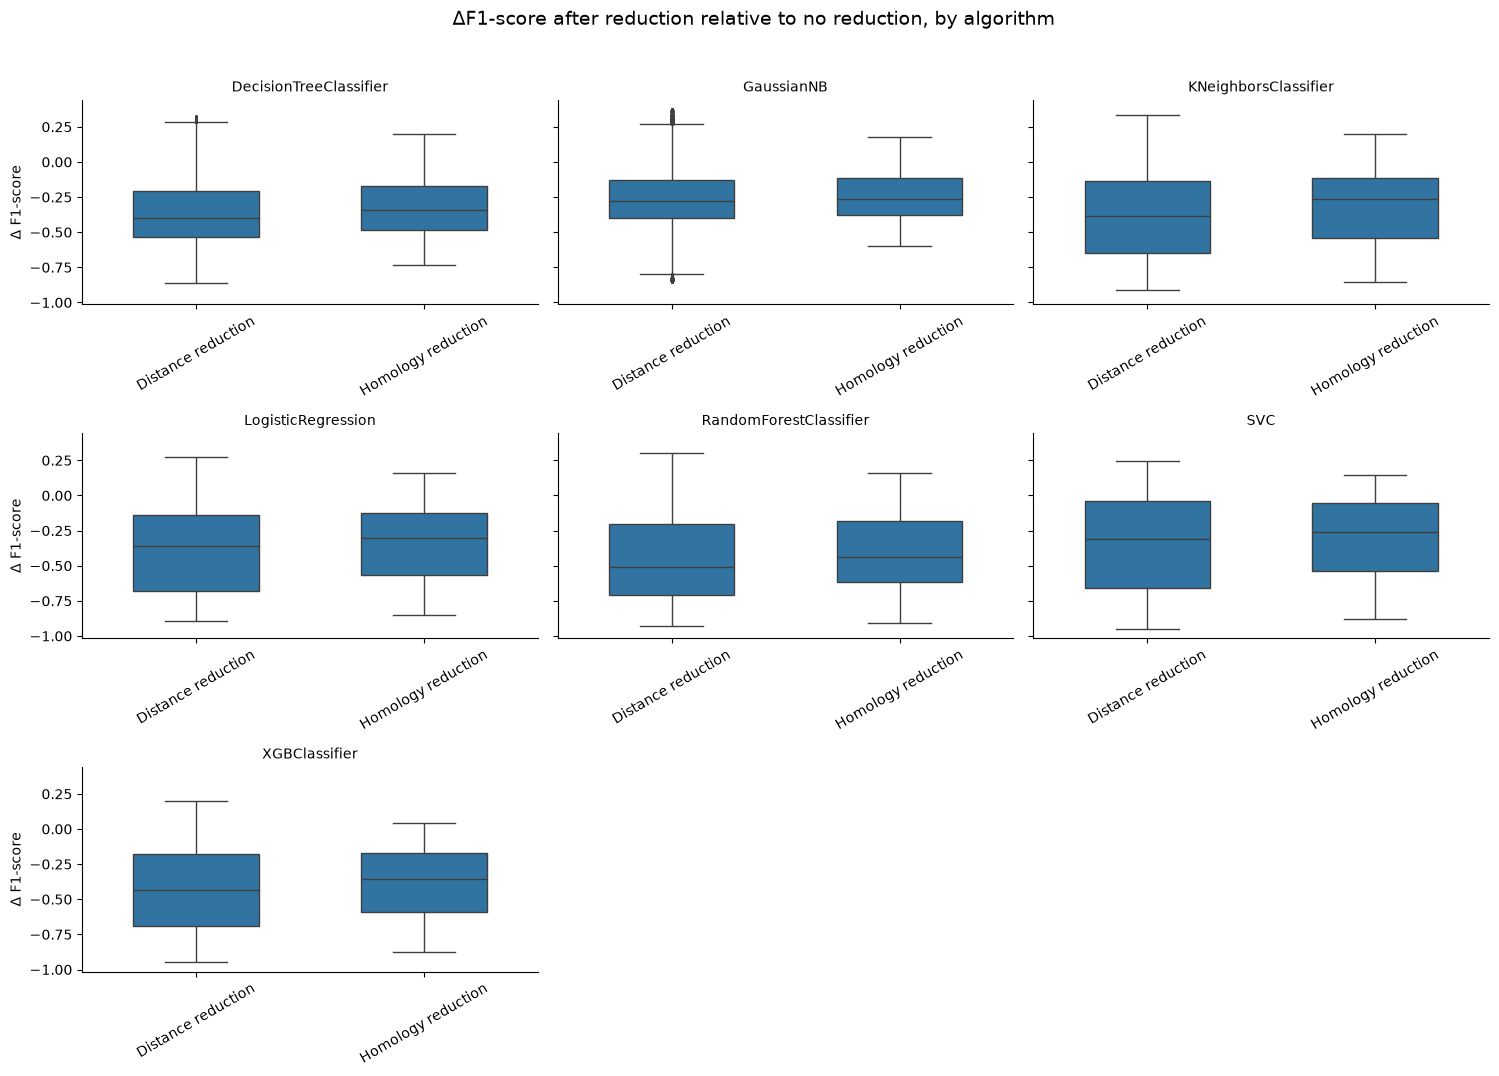

In [48]:
plot_reduction_delta_by_algorithm(
    delta_reduction_f1,
    ylabel="Δ F1-score",
    title="ΔF1-score after reduction relative to no reduction, by algorithm"
)

- Delta of partition by representation

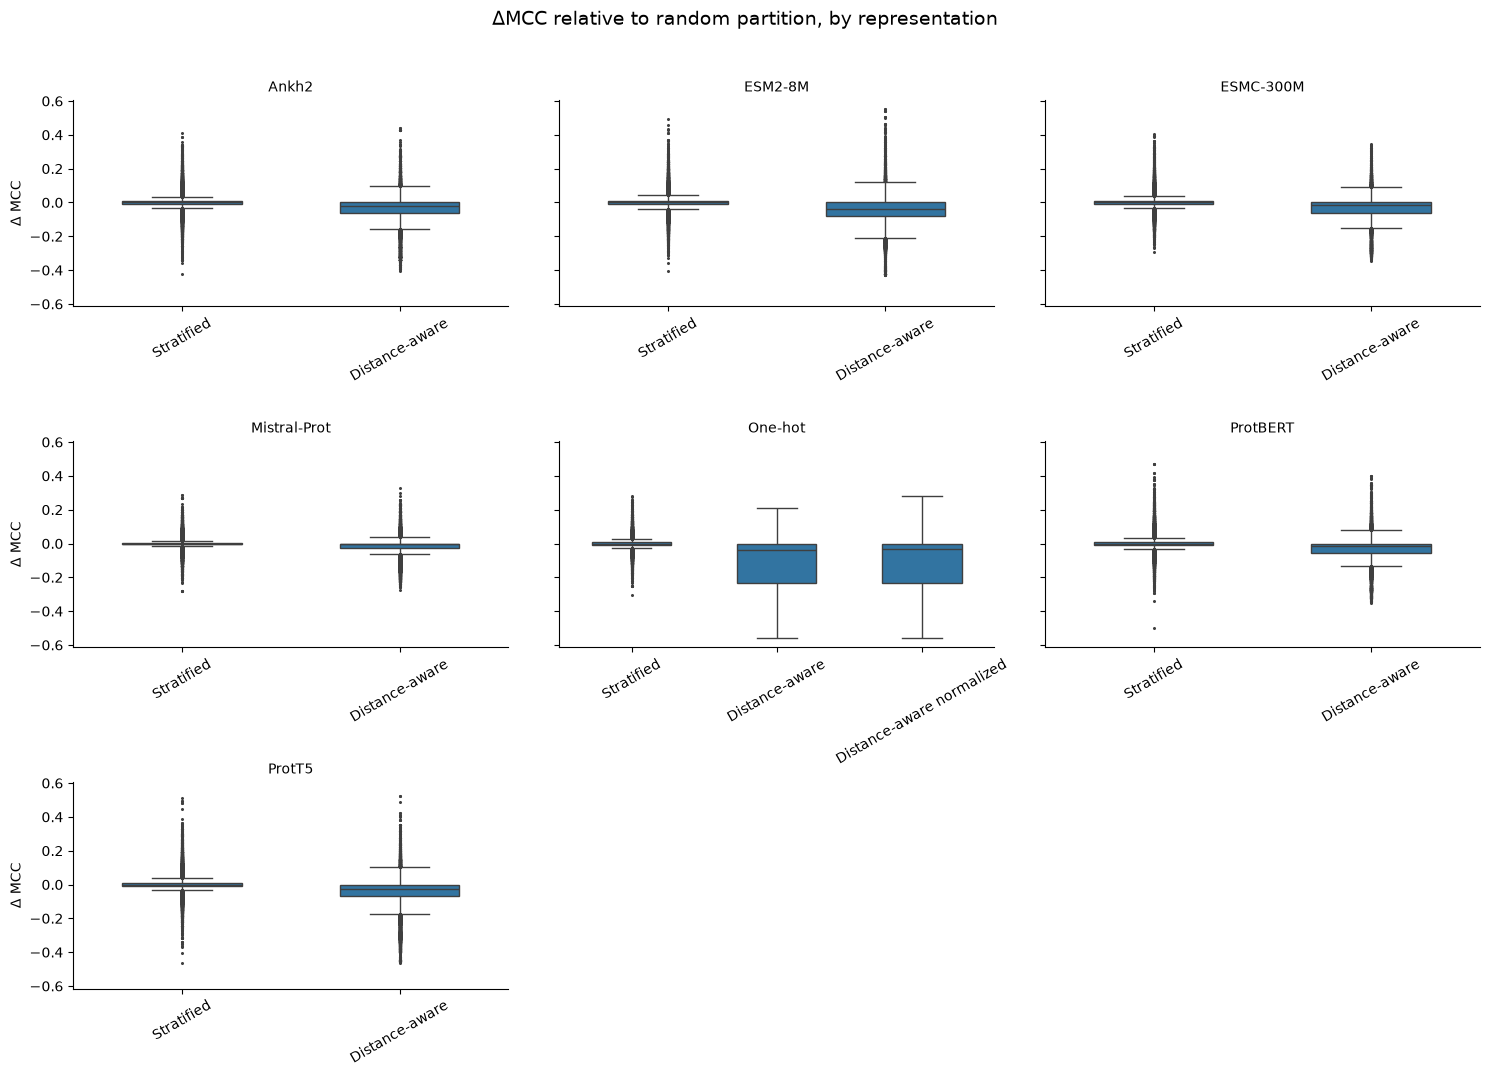

In [49]:
plot_partition_delta_by_representation(
    delta_partition_mcc,
    ylabel="Δ MCC",
    title="ΔMCC relative to random partition, by representation"
)

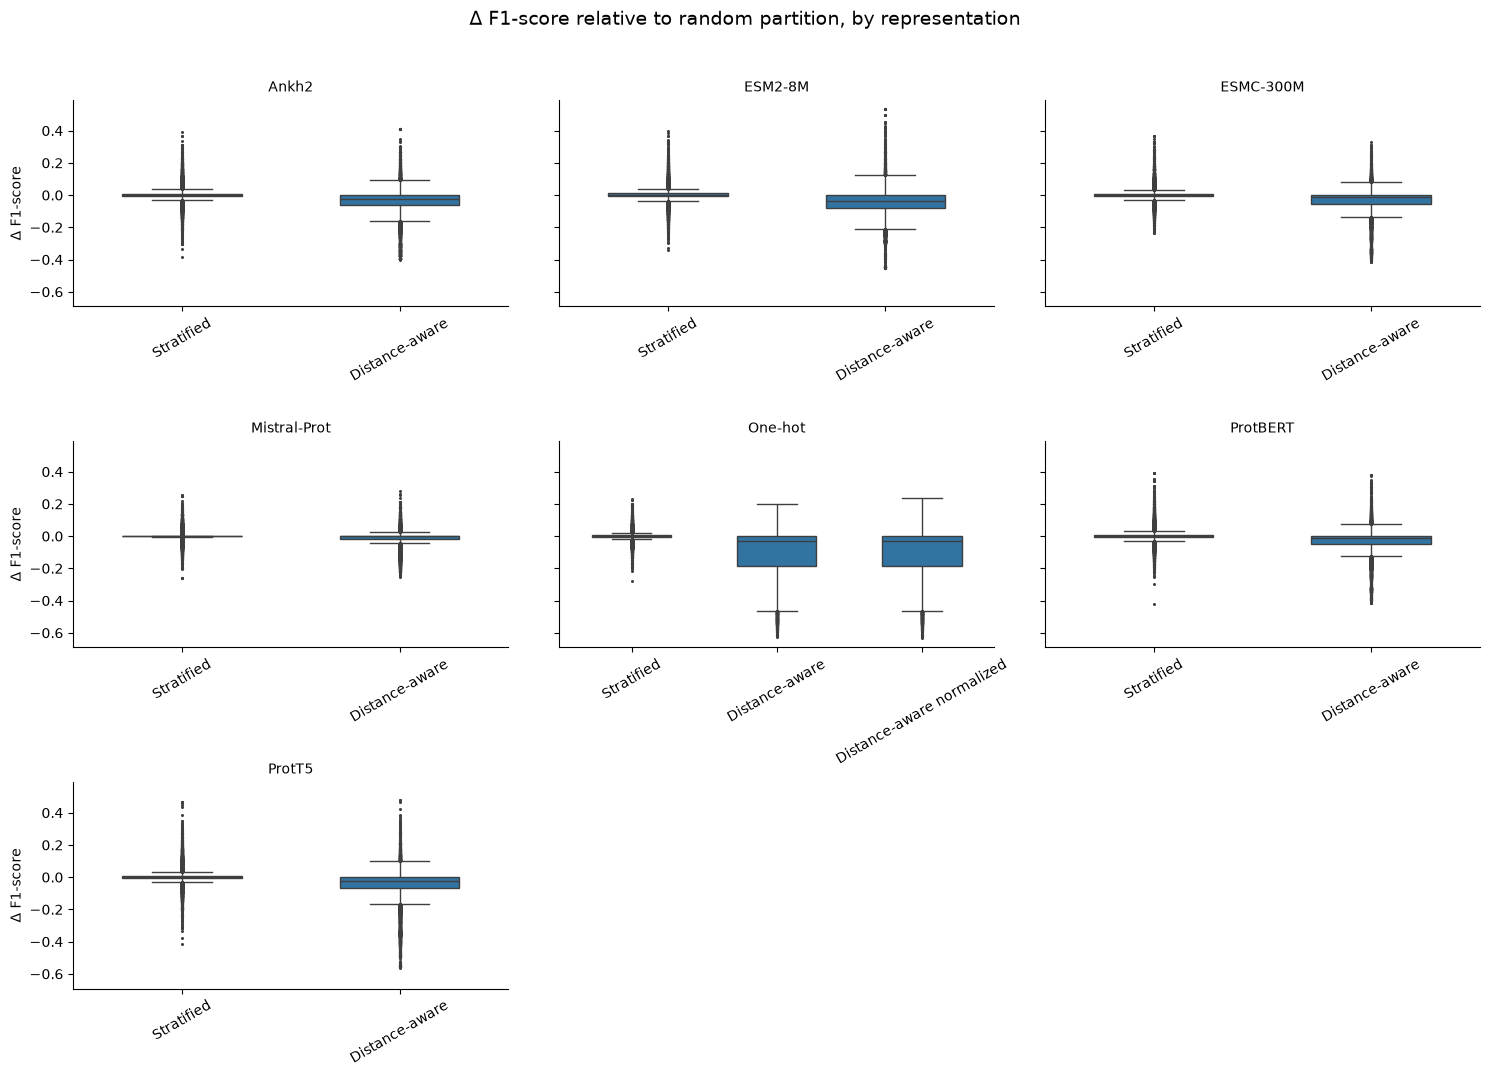

In [50]:
plot_partition_delta_by_representation(
    delta_partition_f1,
    ylabel="Δ F1-score",
    title="Δ F1-score relative to random partition, by representation"
)

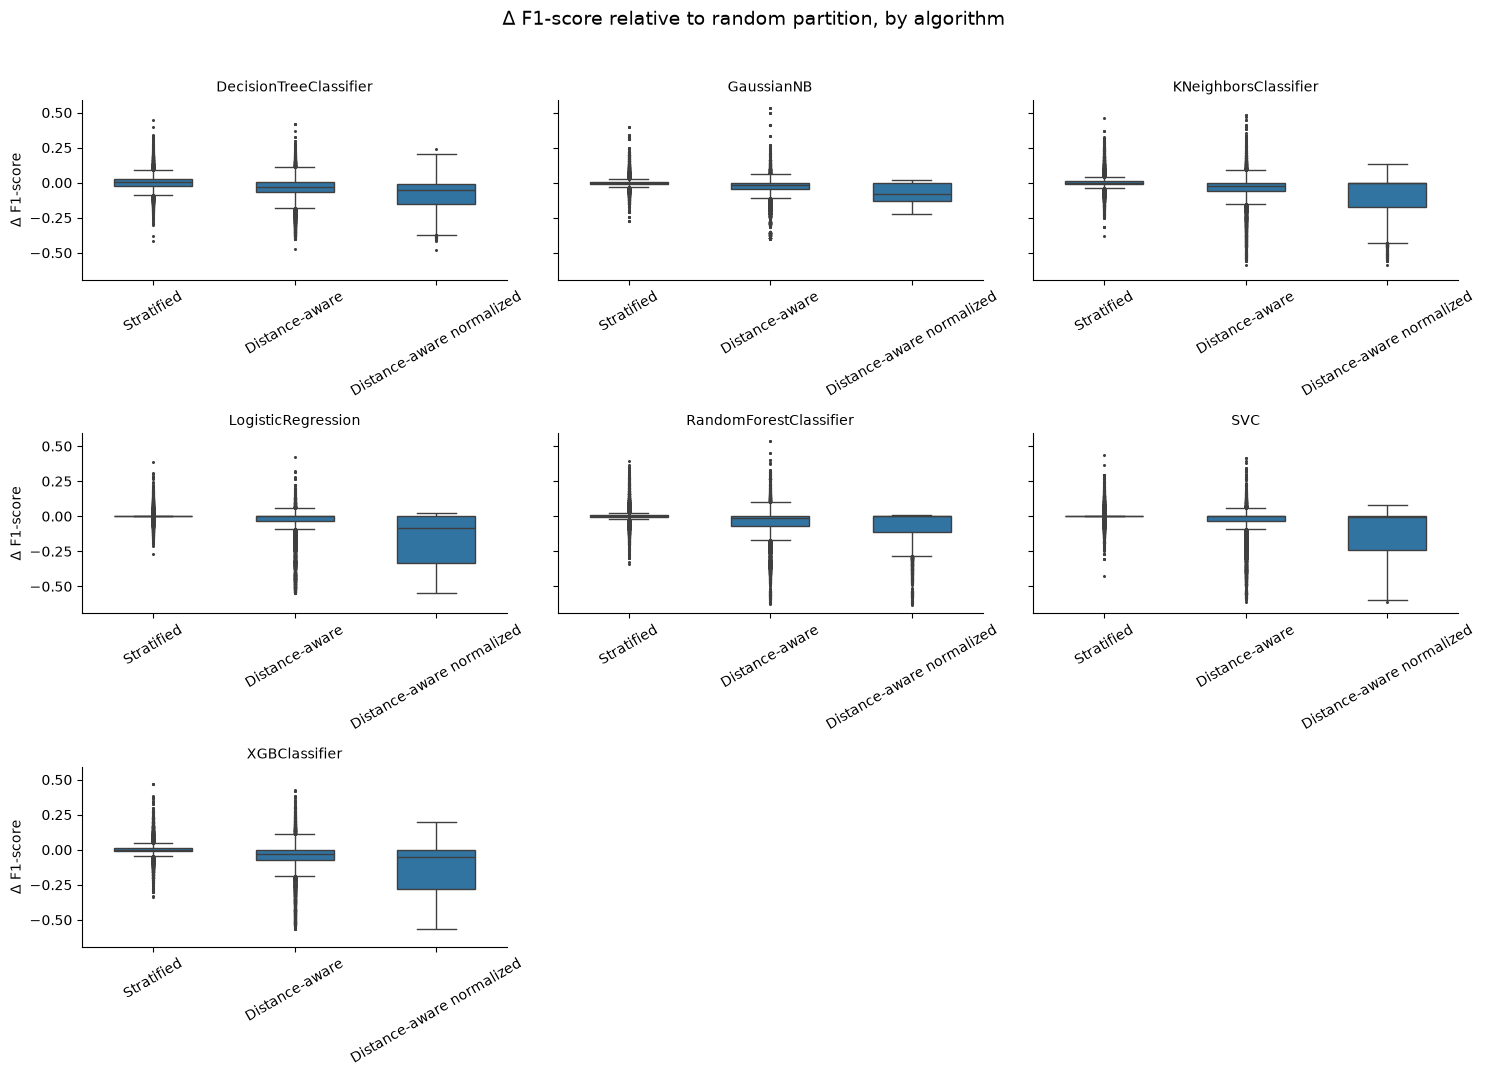

In [51]:
plot_partition_delta_by_algorithm(
    delta_partition_f1,
    ylabel="Δ F1-score",
    title="Δ F1-score relative to random partition, by algorithm"
)

- Delta reduction heatmap: representation × algorithm. Which algorithms and representations are most affected by reduction?

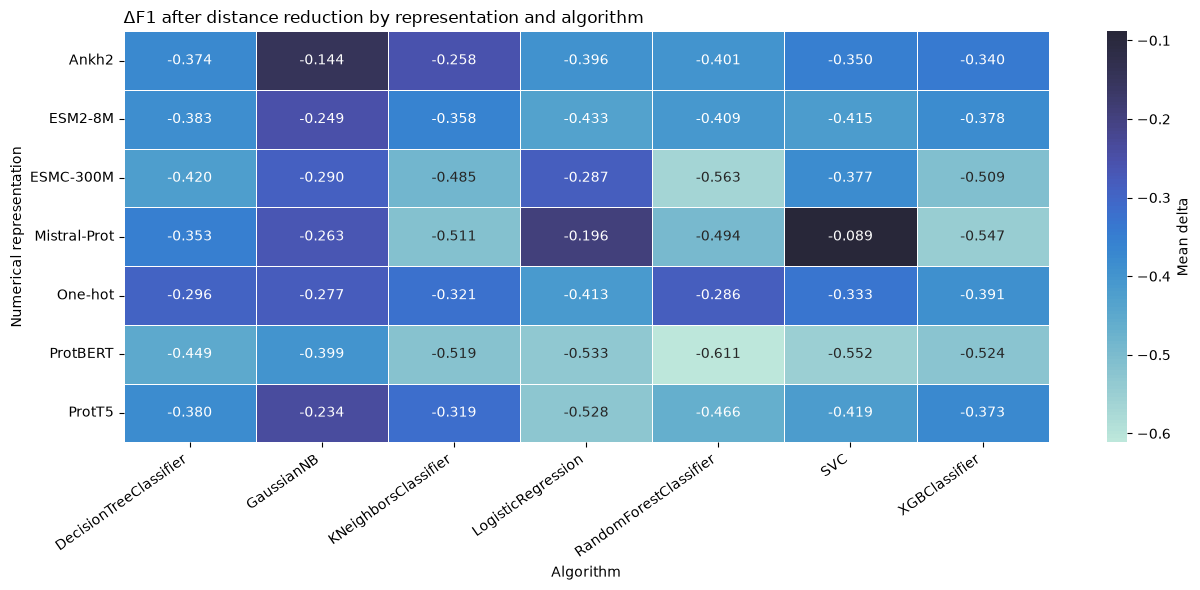

In [52]:
plot_delta_reduction_representation_algorithm_heatmap(
    delta_reduction_f1,
    reduction_type="distance_reduction",
    title="ΔF1 after distance reduction by representation and algorithm"
)

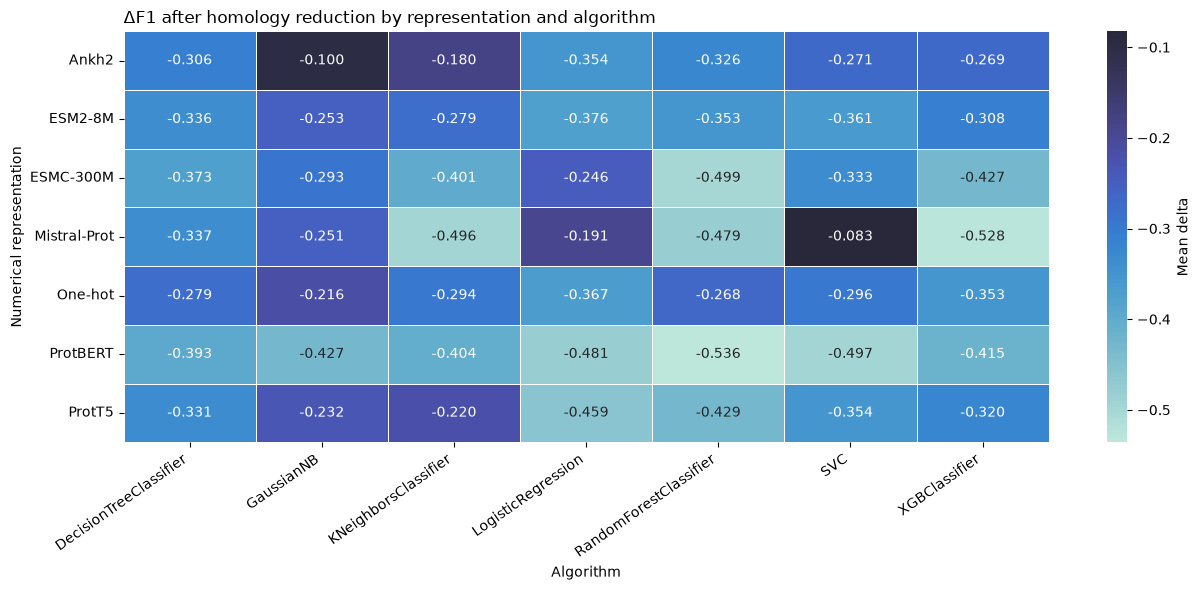

In [53]:
plot_delta_reduction_representation_algorithm_heatmap(
    delta_reduction_f1,
    reduction_type="homology_reduction",
    title="ΔF1 after homology reduction by representation and algorithm"
)

- Delta partition heatmap: representation × algorithm

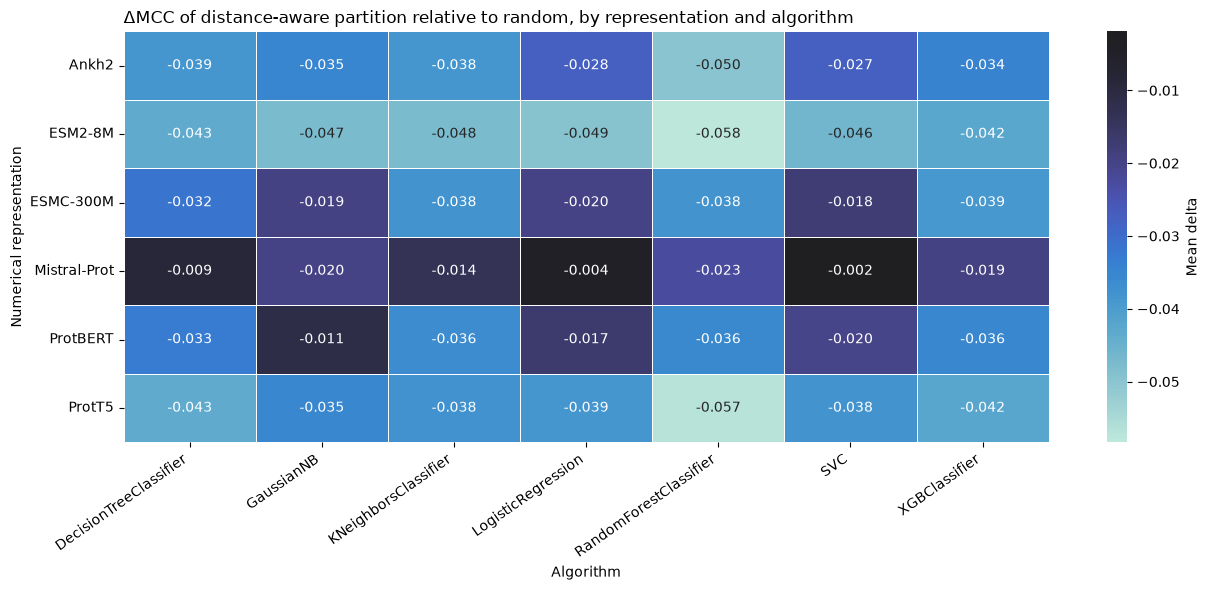

In [54]:
plot_delta_partition_representation_algorithm_heatmap(
    delta_partition_mcc,
    partition_strategy="distance_aware_kfold",
    title="ΔMCC of distance-aware partition relative to random, by representation and algorithm"
)

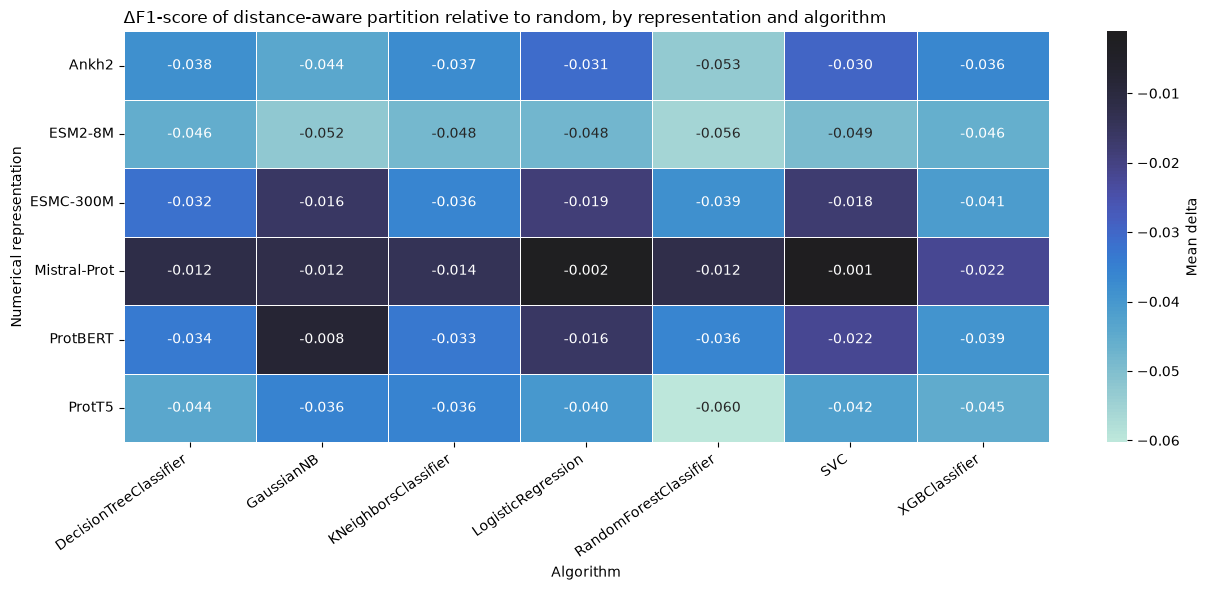

In [55]:
plot_delta_partition_representation_algorithm_heatmap(
    delta_partition_f1,
    partition_strategy="distance_aware_kfold",
    title="ΔF1-score of distance-aware partition relative to random, by representation and algorithm"
)

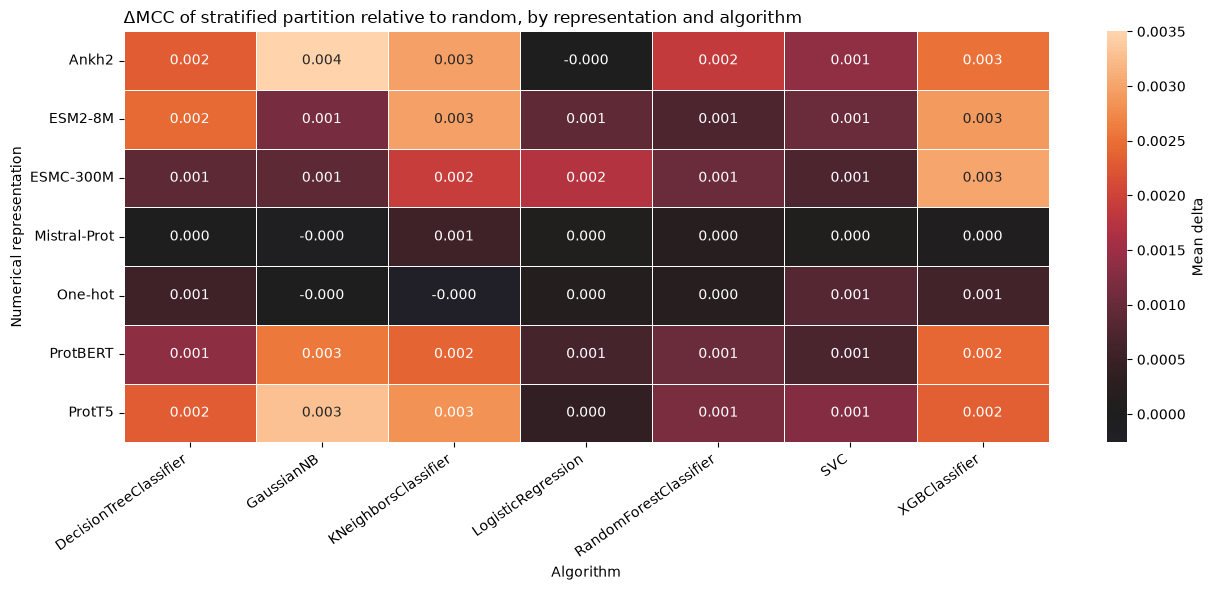

In [56]:
plot_delta_partition_representation_algorithm_heatmap(
    delta_partition_mcc,
    partition_strategy="stratified_kfold",
    title="ΔMCC of stratified partition relative to random, by representation and algorithm"
)

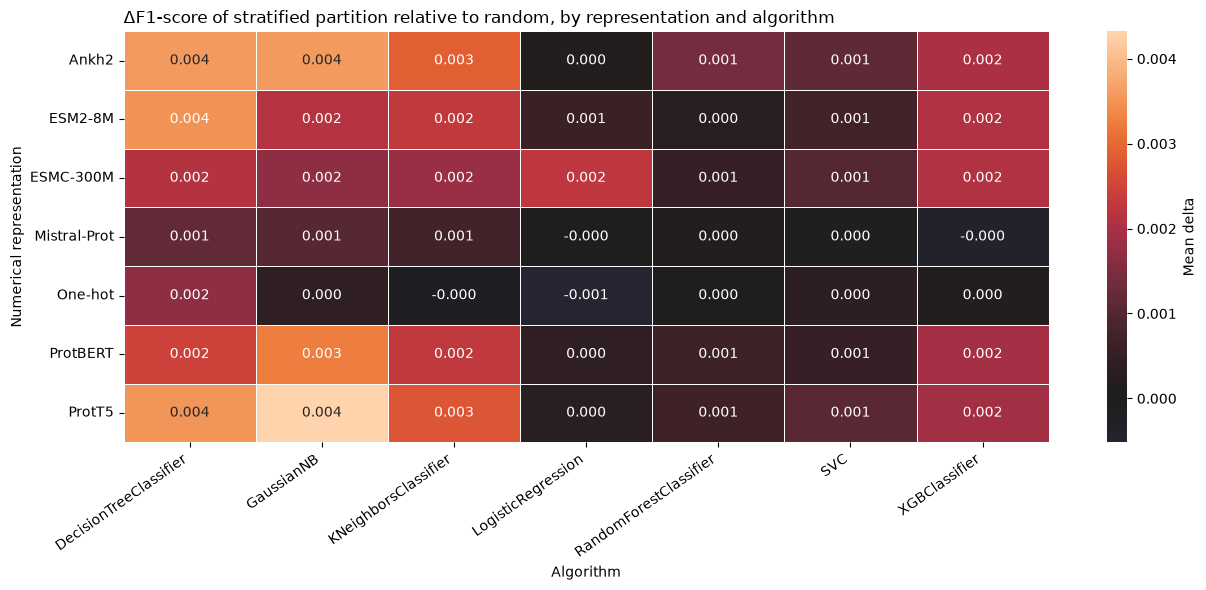

In [57]:
plot_delta_partition_representation_algorithm_heatmap(
    delta_partition_f1,
    partition_strategy="stratified_kfold",
    title="ΔF1-score of stratified partition relative to random, by representation and algorithm"
)

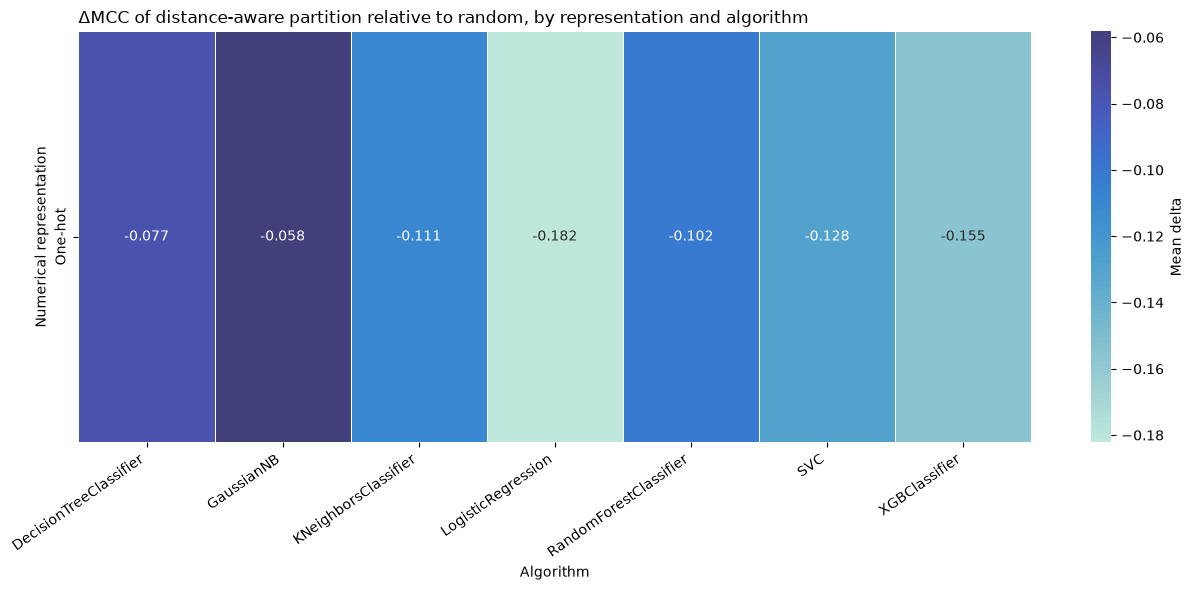

In [58]:
plot_delta_partition_representation_algorithm_heatmap(
    delta_partition_mcc,
    partition_strategy="distance_aware_kfold_norm",
    title="ΔMCC of distance-aware partition relative to random, by representation and algorithm"
)

In [59]:
delta_reduction_f1 = compute_reduction_delta(
    results,
    metric="f1_test_mean",
    reference_reduction="no_reduction"
)

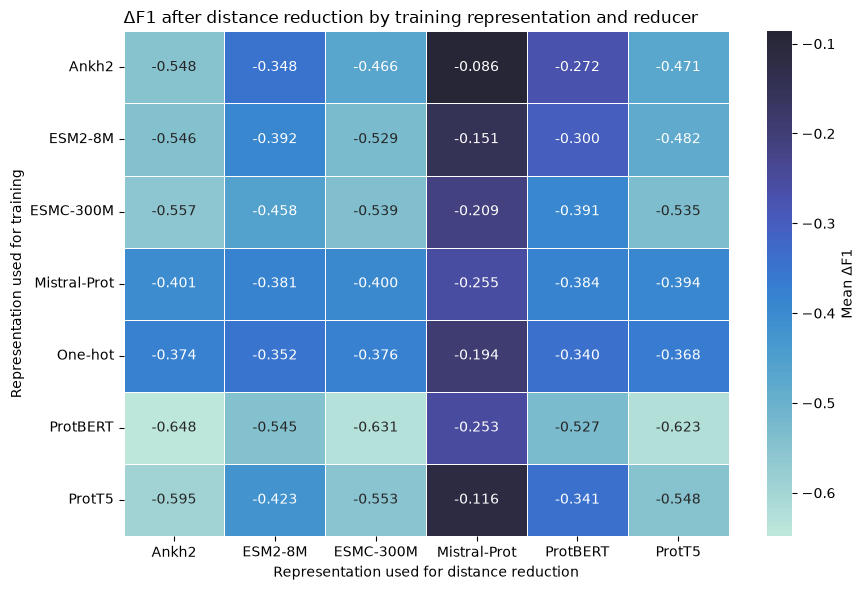

reduced_by_label,Ankh2,ESM2-8M,ESMC-300M,Mistral-Prot,ProtBERT,ProtT5
representation_label,,,,,,
Ankh2,-0.547734,-0.347548,-0.466196,-0.086258,-0.272366,-0.470519
ESM2-8M,-0.545898,-0.392132,-0.528618,-0.151030,-0.299590,-0.482202
ESMC-300M,-0.557284,-0.458035,-0.539413,-0.209286,-0.390721,-0.535266
Mistral-Prot,-0.401006,-0.381494,-0.399874,-0.254845,-0.384432,-0.394107
One-hot,-0.374103,-0.351553,-0.375978,-0.193640,-0.340179,-0.367751
ProtBERT,-0.648174,-0.545322,-0.631438,-0.252556,-0.526583,-0.622641
ProtT5,-0.594915,-0.423191,-0.553367,-0.115839,-0.341454,-0.548364


In [60]:
plot_delta_training_rep_by_reducer_heatmap(
    delta_reduction_f1,
    title="ΔF1 after distance reduction by training representation and reducer"
)

In [61]:
delta_partition_reduction_f1 = compute_partition_reduction_delta(
    results,
    metric="f1_test_mean",
    reference_partition="random_kfold",
    reference_reduction="no_reduction"
)

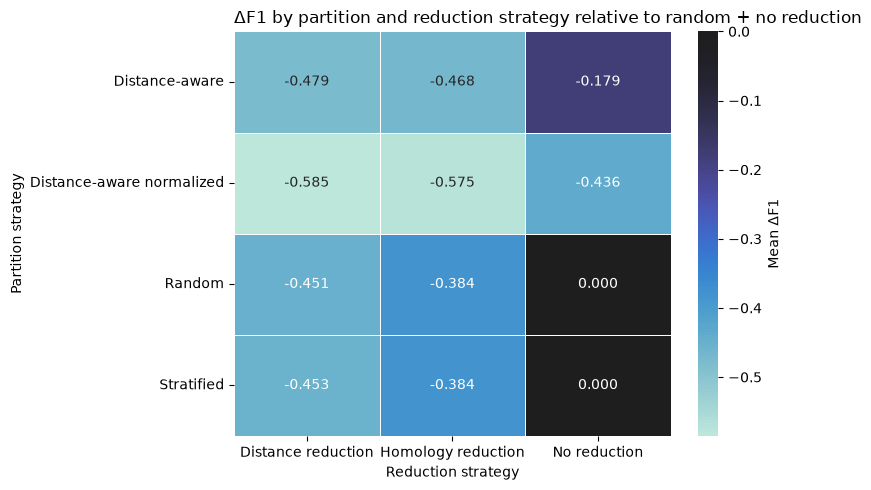

reduction_label,Distance reduction,Homology reduction,No reduction
partition_label,,,
Distance-aware,-0.478722,-0.468290,-0.179188
Distance-aware normalized,-0.585343,-0.574998,-0.436128
Random,-0.450549,-0.383571,0.000000
Stratified,-0.452829,-0.383552,0.000120


In [62]:
plot_partition_reduction_delta_heatmap(
    delta_partition_reduction_f1,
    title="ΔF1 by partition and reduction strategy relative to random + no reduction"
)

- Scale effect

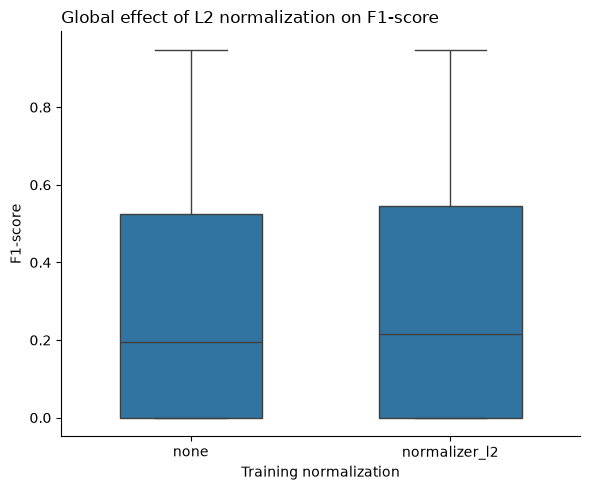

In [63]:
plot_scaler_effect_global(
    results,
    metric="f1_test_mean",
    ylabel="F1-score",
    title="Global effect of L2 normalization on F1-score"
)

In [64]:
delta_scaler_f1 = compute_scaler_delta(
    results,
    metric="f1_test_mean",
    reference_scaler="none",
    comparison_scaler="normalizer_l2"
)

delta_scaler_f1.shape

(902544, 53)

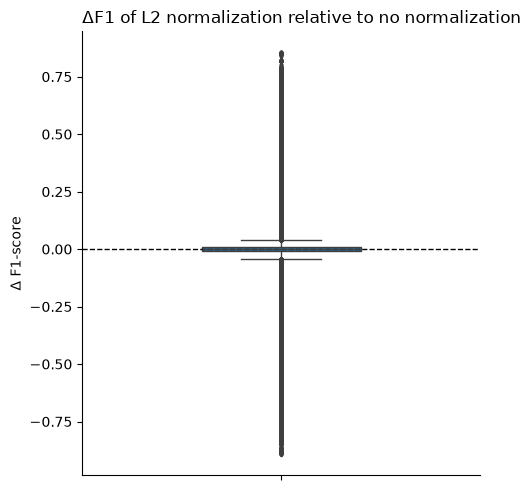

In [65]:
plot_scaler_delta_global(
    delta_scaler_f1,
    ylabel="Δ F1-score",
    title="ΔF1 of L2 normalization relative to no normalization"
)

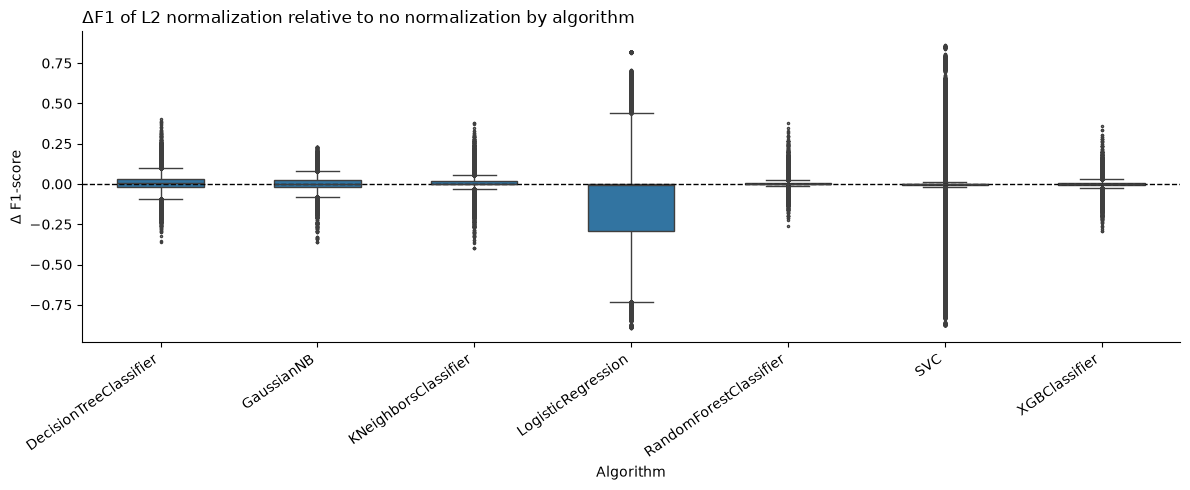

In [66]:
plot_scaler_delta_by_algorithm_simple(
    delta_scaler_f1,
    ylabel="Δ F1-score",
    title="ΔF1 of L2 normalization relative to no normalization by algorithm"
)

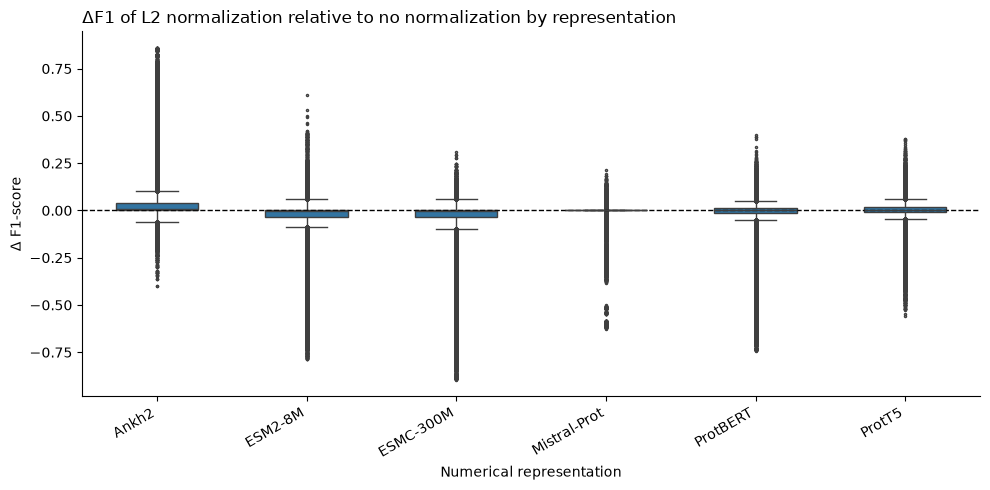

In [67]:
plot_scaler_delta_by_representation_simple(
    delta_scaler_f1,
    ylabel="Δ F1-score",
    title="ΔF1 of L2 normalization relative to no normalization by representation"
)

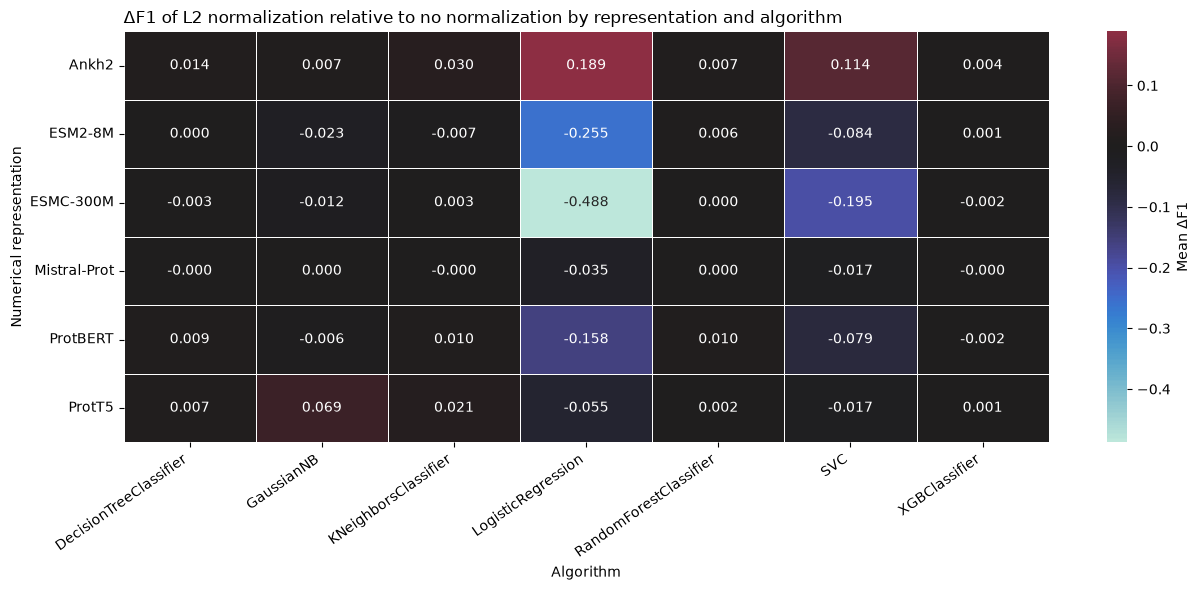

In [68]:
plot_scaler_delta_representation_algorithm_heatmap(
    delta_scaler_f1,
    title="ΔF1 of L2 normalization relative to no normalization by representation and algorithm"
)

- Save analysis outputs for downstream notebooks

In [69]:
ANALYSIS_DIR = Path(folder_path)
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

# 1. Main cleaned table with readable labels
results.to_csv(
    ANALYSIS_DIR / "results_prepared_for_analysis.csv",
    index=False
)

# 2. Partition deltas
delta_partition_f1.to_csv(
    ANALYSIS_DIR / "delta_partition_f1.csv",
    index=False
)

delta_partition_mcc.to_csv(
    ANALYSIS_DIR / "delta_partition_mcc.csv",
    index=False
)

# 3. Reduction deltas
delta_reduction_f1.to_csv(
    ANALYSIS_DIR / "delta_reduction_f1.csv",
    index=False
)

delta_reduction_mcc.to_csv(
    ANALYSIS_DIR / "delta_reduction_mcc.csv",
    index=False
)

# 4. Training normalization delta
delta_scaler_f1.to_csv(
    ANALYSIS_DIR / "delta_scaler_f1.csv",
    index=False
)

# 5. Combined partition × reduction delta
delta_partition_reduction_f1.to_csv(
    ANALYSIS_DIR / "delta_partition_reduction_f1.csv",
    index=False
)

# 6. Metadata for reproducibility
analysis_metadata = {
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "base_path": str(ANALYSIS_DIR),
    "input_file": str(ANALYSIS_DIR / "all_results_aggregated_final.csv"),
    "excluded_algorithm": "LGBMClassifier",
    "n_rows_results_all_after_filter": int(results_all.shape[0]),
    "n_rows_results_prepared": int(results.shape[0]),
    "n_delta_partition_f1": int(delta_partition_f1.shape[0]),
    "n_delta_partition_mcc": int(delta_partition_mcc.shape[0]),
    "n_delta_reduction_f1": int(delta_reduction_f1.shape[0]),
    "n_delta_reduction_mcc": int(delta_reduction_mcc.shape[0]),
    "n_delta_scaler_f1": int(delta_scaler_f1.shape[0]),
    "n_delta_partition_reduction_f1": int(delta_partition_reduction_f1.shape[0]),
    "label_maps": {
        "REP_LABELS": REP_LABELS,
        "PARTITION_LABELS": PARTITION_LABELS,
        "REDUCTION_LABELS": REDUCTION_LABELS,
    },
}

with open(ANALYSIS_DIR / "analysis_metadata.json", "w") as f:
    json.dump(analysis_metadata, f, indent=4)

print(f"Saved analysis outputs to: {ANALYSIS_DIR}")

Saved analysis outputs to: ../../analysed_training
